
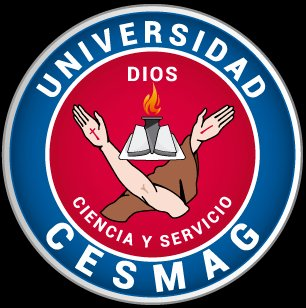

In [1]:
#@title  Notebook 05B — Cross-Patient LOPO ECG
#@markdown (portada — no modificar)
from IPython.display import display, HTML
display(HTML("""
  <!DOCTYPE html>
<html lang="es">
<head>
<meta charset="UTF-8">
<style>
  @import url('https://fonts.googleapis.com/css2?family=Crimson+Pro:ital,wght@0,300;0,400;0,600;1,300&family=JetBrains+Mono:wght@400;600&family=Barlow+Condensed:wght@300;400;700;900&display=swap');

  :root {
    --azul-cesmag: #003b7a;
    --rojo-cesmag: #c0002a;
    --dorado: #c9a84c;
    --gris-oscuro: #1a1a2e;
    --blanco: #ffffff;
    --verde-ok: #2d9c5a;
    --pulso: #e8325a;
  }

  * { margin: 0; padding: 0; box-sizing: border-box; }
  body { font-family: 'Barlow Condensed', sans-serif; background: transparent; }

  .wrapper {
    width: 100%; background: var(--gris-oscuro); border-radius: 16px;
    overflow: hidden; position: relative; box-shadow: 0 24px 80px rgba(0,0,0,0.5);
  }

  .ecg-bg { position: absolute; top: 0; left: 0; right: 0; bottom: 0; opacity: 0.04; pointer-events: none; overflow: hidden; }
  .ecg-bg svg { width: 200%; height: 100%; animation: scrollECG 18s linear infinite; }
  @keyframes scrollECG { from { transform: translateX(0); } to { transform: translateX(-50%); } }

  .header {
    background: linear-gradient(135deg, var(--azul-cesmag) 0%, #001f4d 60%, #0a0a2a 100%);
    padding: 36px 48px 28px; display: grid; grid-template-columns: 110px 1fr;
    gap: 32px; align-items: center; position: relative; border-bottom: 3px solid var(--dorado);
  }
  .header::after {
    content: ''; position: absolute; bottom: -3px; left: 0; right: 0; height: 1px;
    background: linear-gradient(90deg, transparent, var(--dorado), transparent);
  }
  .logo-ring {
    width: 110px; height: 110px; border-radius: 50%; padding: 4px;
    background: conic-gradient(var(--dorado), var(--rojo-cesmag), var(--dorado));
    animation: rotatering 8s linear infinite; flex-shrink: 0;
  }
  @keyframes rotatering { to { filter: hue-rotate(30deg); } }
  .logo-inner { width: 100%; height: 100%; border-radius: 50%; overflow: hidden; border: 3px solid var(--gris-oscuro); }
  .logo-inner img { width: 100%; height: 100%; object-fit: cover; }

  .univ-label { font-weight: 300; font-size: 11px; letter-spacing: 4px; color: var(--dorado); text-transform: uppercase; margin-bottom: 4px; }
  .univ-name { font-weight: 900; font-size: 28px; color: var(--blanco); letter-spacing: 1px; line-height: 1; }
  .dept { font-size: 13px; font-weight: 400; color: rgba(255,255,255,0.6); letter-spacing: 2px; margin-top: 6px; }
  .notebook-badge {
    display: inline-flex; align-items: center; gap: 8px; background: var(--rojo-cesmag);
    color: white; font-family: 'JetBrains Mono', monospace; font-size: 11px; font-weight: 600;
    padding: 5px 14px; border-radius: 4px; margin-top: 12px; letter-spacing: 1px;
  }
  .notebook-badge::before { content: '▶'; font-size: 8px; }

  .title-section { padding: 32px 48px 24px; background: #111128; }
  .title-label { font-size: 10px; letter-spacing: 5px; color: var(--pulso); text-transform: uppercase; margin-bottom: 10px; font-weight: 400; }
  .main-title { font-family: 'Crimson Pro', serif; font-size: 34px; font-weight: 600; color: var(--blanco); line-height: 1.25; max-width: 820px; }
  .main-title em { font-style: italic; color: var(--dorado); }
  .subtitle { font-size: 14px; color: rgba(255,255,255,0.45); margin-top: 10px; letter-spacing: 1px; font-weight: 300; }

  .stats-band {
    display: grid; grid-template-columns: repeat(4, 1fr); background: #0c0c22;
    border-top: 1px solid rgba(201,168,76,0.2); border-bottom: 1px solid rgba(201,168,76,0.2);
  }
  .stat-box { padding: 18px 20px; text-align: center; border-right: 1px solid rgba(255,255,255,0.06); transition: background 0.3s; }
  .stat-box:last-child { border-right: none; }
  .stat-box:hover { background: rgba(201,168,76,0.05); }
  .stat-num { font-family: 'JetBrains Mono', monospace; font-size: 28px; font-weight: 600; color: var(--dorado); line-height: 1; }
  .stat-num span { font-size: 14px; color: rgba(201,168,76,0.6); }
  .stat-desc { font-size: 10px; letter-spacing: 2px; color: rgba(255,255,255,0.4); text-transform: uppercase; margin-top: 5px; }

  .body-grid { display: grid; grid-template-columns: 1fr 1fr; background: #12122a; }
  .section { padding: 28px 32px; border-right: 1px solid rgba(255,255,255,0.05); border-bottom: 1px solid rgba(255,255,255,0.05); }
  .section:nth-child(even) { border-right: none; }

  .sec-title {
    font-size: 9px; letter-spacing: 4px; text-transform: uppercase; color: var(--pulso);
    margin-bottom: 14px; display: flex; align-items: center; gap: 8px;
  }
  .sec-title::after { content: ''; flex: 1; height: 1px; background: rgba(232,50,90,0.3); }

  .model-list { display: flex; flex-direction: column; gap: 7px; }
  .model-item {
    display: flex; align-items: center; gap: 10px; padding: 8px 12px;
    background: rgba(255,255,255,0.03); border-radius: 6px;
    border-left: 3px solid transparent; transition: border-color 0.2s, background 0.2s;
  }
  .model-item:hover { background: rgba(255,255,255,0.07); }
  .model-item.winner { border-left-color: var(--dorado); }
  .model-item.good   { border-left-color: var(--verde-ok); }
  .model-item.bad    { border-left-color: var(--rojo-cesmag); }
  .model-tag { font-family: 'JetBrains Mono', monospace; font-size: 11px; font-weight: 600; color: var(--blanco); min-width: 90px; }
  .model-score { font-family: 'JetBrains Mono', monospace; font-size: 11px; color: rgba(255,255,255,0.5); margin-left: auto; }
  .crown { font-size: 10px; }

  .chip-grid { display: flex; flex-wrap: wrap; gap: 6px; }
  .chip { font-family: 'JetBrains Mono', monospace; font-size: 10px; padding: 4px 10px; border-radius: 4px; background: rgba(0,59,122,0.4); border: 1px solid rgba(0,59,122,0.8); color: rgba(255,255,255,0.8); letter-spacing: 0.5px; }
  .chip.highlight { background: rgba(201,168,76,0.15); border-color: rgba(201,168,76,0.5); color: var(--dorado); }
  .chip.ft { background: rgba(45,156,90,0.15); border-color: rgba(45,156,90,0.4); color: #5de89e; }

  .metric-row { display: flex; justify-content: space-between; align-items: center; padding: 7px 0; border-bottom: 1px solid rgba(255,255,255,0.04); font-size: 12px; }
  .metric-row:last-child { border-bottom: none; }
  .metric-name { color: rgba(255,255,255,0.5); font-weight: 300; letter-spacing: 1px; }
  .metric-val { font-family: 'JetBrains Mono', monospace; font-size: 11px; color: var(--blanco); background: rgba(255,255,255,0.06); padding: 2px 8px; border-radius: 3px; }

  .file-list { display: flex; flex-direction: column; gap: 5px; }
  .file-item { display: flex; align-items: center; gap: 8px; font-family: 'JetBrains Mono', monospace; font-size: 10px; color: rgba(255,255,255,0.55); padding: 5px 8px; border-radius: 4px; background: rgba(255,255,255,0.02); }
  .ftype { font-size: 8px; padding: 1px 5px; border-radius: 2px; font-weight: 600; letter-spacing: 1px; }
  .ftype.csv   { background: rgba(45,156,90,0.3);  color: #5de89e; }
  .ftype.png   { background: rgba(201,168,76,0.3); color: var(--dorado); }
  .ftype.json  { background: rgba(0,59,122,0.5);   color: #5fa8ff; }
  .ftype.keras { background: rgba(232,50,90,0.3);  color: #ff7a9a; }

  .authors-bar {
    background: linear-gradient(90deg, #001530, #0a0a2a, #001530);
    padding: 20px 48px; display: flex; align-items: center;
    justify-content: space-between; flex-wrap: wrap; gap: 16px;
    border-top: 1px solid rgba(201,168,76,0.2);
  }
  .authors-group { display: flex; flex-direction: column; gap: 6px; }
  .author-label { font-size: 8px; letter-spacing: 4px; text-transform: uppercase; color: rgba(255,255,255,0.3); }
  .author-names { display: flex; gap: 20px; flex-wrap: wrap; }
  .author { font-family: 'Crimson Pro', serif; font-size: 16px; color: var(--blanco); font-weight: 400; letter-spacing: 0.5px; }
  .asesor-block { text-align: right; }
  .asesor-name { font-family: 'Crimson Pro', serif; font-size: 15px; color: var(--dorado); font-style: italic; }

  .footer { background: #0a0a18; padding: 12px 48px; display: flex; justify-content: space-between; align-items: center; }
  .footer-date { font-family: 'JetBrains Mono', monospace; font-size: 10px; color: rgba(255,255,255,0.2); letter-spacing: 2px; }
  .footer-file { font-family: 'JetBrains Mono', monospace; font-size: 10px; color: rgba(232,50,90,0.5); letter-spacing: 1px; }

  .pulse-line { width: 100%; height: 40px; background: #0a0a18; position: relative; overflow: hidden; }
  .pulse-line svg { position: absolute; top: 0; left: 0; width: 200%; animation: pulsemove 3s linear infinite; }
  @keyframes pulsemove { from { transform: translateX(0); } to { transform: translateX(-50%); } }
</style>
</head>
<body>
<div class="wrapper">

  <div class="ecg-bg">
    <svg viewBox="0 0 1400 200" preserveAspectRatio="none" xmlns="http://www.w3.org/2000/svg">
      <polyline points="0,100 80,100 100,100 110,20 120,180 130,60 140,140 150,100 230,100 310,100 320,100 330,20 340,180 350,60 360,140 370,100 450,100 530,100 540,100 550,20 560,180 570,60 580,140 590,100 670,100 750,100 760,100 770,20 780,180 790,60 800,140 810,100 890,100 970,100 980,100 990,20 1000,180 1010,60 1020,140 1030,100 1110,100 1190,100 1200,100 1210,20 1220,180 1230,60 1240,140 1250,100 1330,100 1400,100" stroke="white" stroke-width="2" fill="none"/>
    </svg>
  </div>

  <!-- HEADER -->
  <div class="header">
    <div class="logo-ring">
      <div class="logo-inner">
        <img src="..." alt="Logo CESMAG">
      </div>
    </div>
    <div>
      <div class="univ-label">Universidad</div>
      <div class="univ-name">CESMAG</div>
      <div class="dept">Ingeniería de Sistemas · Grupo de Investigación</div>
      <div class="notebook-badge">05_cross_patient.ipynb</div>
    </div>
  </div>

  <!-- TÍTULO -->
  <div class="title-section">
    <div class="title-label">Notebook 05B — Evaluación Cross-Patient · Quinta Fase Experimental</div>
    <div class="main-title">
      Generalización <em>Cross-Patient</em> via<br>Leave-One-Patient-Out (LOPO) con Fine-Tuning
    </div>
    <div class="subtitle">MIT-BIH · 48 folds LOPO · 35 250 ventanas/fold · 8 configuraciones · Lookback = 5 latidos · F_N+PB+MED</div>
  </div>

  <!-- STATS -->
  <div class="stats-band">
    <div class="stat-box">
      <div class="stat-num">384</div>
      <div class="stat-desc">Evaluaciones LOPO</div>
    </div>
    <div class="stat-box">
      <div class="stat-num">8</div>
      <div class="stat-desc">Configuraciones</div>
    </div>
    <div class="stat-box">
      <div class="stat-num">15</div>
      <div class="stat-desc">Muestras fine-tune</div>
    </div>
    <div class="stat-box">
      <div class="stat-num">0.548</div>
      <div class="stat-desc">Mejor R² (Ens. FT)</div>
    </div>
  </div>

  <!-- BODY GRID -->
  <div class="body-grid">

    <!-- Ranking global -->
    <div class="section">
      <div class="sec-title">Ranking Global · Base + Fine-Tune + Ensamble</div>
      <div class="model-list">
        <div class="model-item winner">
          <span class="crown">👑</span>
          <span class="model-tag">Ensemble_FT</span>
          <span style="font-size:10px;color:rgba(255,255,255,0.4);">Promedio FT</span>
          <span class="model-score">R²= 0.548</span>
        </div>
        <div class="model-item winner">
          <span class="crown">·</span>
          <span class="model-tag">Ensemble</span>
          <span style="font-size:10px;color:rgba(255,255,255,0.4);">Promedio base</span>
          <span class="model-score">R²= 0.540</span>
        </div>
        <div class="model-item good">
          <span class="crown">·</span>
          <span class="model-tag">CNN_GRU_FT</span>
          <span style="font-size:10px;color:rgba(255,255,255,0.4);">Individual FT</span>
          <span class="model-score">R²= 0.535</span>
        </div>
        <div class="model-item good">
          <span class="crown">·</span>
          <span class="model-tag">CNN_GRU</span>
          <span style="font-size:10px;color:rgba(255,255,255,0.4);">Individual base</span>
          <span class="model-score">R²= 0.533</span>
        </div>
        <div class="model-item good">
          <span class="crown">·</span>
          <span class="model-tag">GRU_base_FT</span>
          <span style="font-size:10px;color:rgba(255,255,255,0.4);">Fine-tuned</span>
          <span class="model-score">R²= 0.527</span>
        </div>
        <div class="model-item good">
          <span class="crown">·</span>
          <span class="model-tag">GRU_base</span>
          <span style="font-size:10px;color:rgba(255,255,255,0.4);">Base</span>
          <span class="model-score">R²= 0.525</span>
        </div>
        <div class="model-item bad">
          <span class="crown">·</span>
          <span class="model-tag">BiGRU_MHA_FT</span>
          <span style="font-size:10px;color:rgba(255,255,255,0.4);">Atención FT</span>
          <span class="model-score">R²= 0.457</span>
        </div>
        <div class="model-item bad">
          <span class="crown">·</span>
          <span class="model-tag">BiGRU_MHA</span>
          <span style="font-size:10px;color:rgba(255,255,255,0.4);">Atención base</span>
          <span class="model-score">R²= 0.439</span>
        </div>
      </div>
    </div>

    <!-- Efecto fine-tuning -->
    <div class="section">
      <div class="sec-title">Efecto del Fine-Tuning (15 muestras)</div>
      <div class="model-list">
        <div class="model-item good">
          <span class="crown">↑</span>
          <span class="model-tag">BiGRU_MHA</span>
          <span style="font-size:10px;color:rgba(255,255,255,0.4);">Más beneficiado</span>
          <span class="model-score">+4.15 %</span>
        </div>
        <div class="model-item good">
          <span class="crown">↑</span>
          <span class="model-tag">Ensemble</span>
          <span style="font-size:10px;color:rgba(255,255,255,0.4);">Ensamble</span>
          <span class="model-score">+1.56 %</span>
        </div>
        <div class="model-item good">
          <span class="crown">↑</span>
          <span class="model-tag">GRU_base</span>
          <span style="font-size:10px;color:rgba(255,255,255,0.4);">Marginal</span>
          <span class="model-score">+0.44 %</span>
        </div>
        <div class="model-item good">
          <span class="crown">↑</span>
          <span class="model-tag">CNN_GRU</span>
          <span style="font-size:10px;color:rgba(255,255,255,0.4);">Marginal</span>
          <span class="model-score">+0.34 %</span>
        </div>
      </div>
      <div style="margin-top:14px;">
        <div class="metric-row">
          <span class="metric-name">Protocolo</span>
          <span class="metric-val">LOPO · 48 folds</span>
        </div>
        <div class="metric-row">
          <span class="metric-name">Filtro único</span>
          <span class="metric-val">F_N+PB+MED</span>
        </div>
        <div class="metric-row">
          <span class="metric-name">Ventanas entrenamiento/fold</span>
          <span class="metric-val">35 250</span>
        </div>
        <div class="metric-row">
          <span class="metric-name">Pac. con R² &lt; 0 (CNN_GRU)</span>
          <span class="metric-val">3 pacientes</span>
        </div>
        <div class="metric-row">
          <span class="metric-name">Mejor pac. (Ensemble_FT)</span>
          <span class="metric-val">112 → R²= 0.928</span>
        </div>
        <div class="metric-row">
          <span class="metric-name">Degradación vs NB4B</span>
          <span class="metric-val">−24.2 % (esperado)</span>
        </div>
      </div>
    </div>

    <!-- Arquitecturas y config -->
    <div class="section">
      <div class="sec-title">Arquitecturas y Configuración</div>
      <div class="chip-grid" style="margin-bottom:14px;">
        <span class="chip">GRU_base</span>
        <span class="chip">CNN_GRU</span>
        <span class="chip">BiGRU_MHA</span>
        <span class="chip ft">GRU_base_FT ★</span>
        <span class="chip ft">CNN_GRU_FT ★</span>
        <span class="chip ft">BiGRU_MHA_FT ★</span>
        <span class="chip highlight">Ensemble ★</span>
        <span class="chip highlight">Ensemble_FT 👑</span>
      </div>
      <div class="metric-row">
        <span class="metric-name">Optimizador / Loss</span>
        <span class="metric-val">Adam 0.001 · MSE</span>
      </div>
      <div class="metric-row">
        <span class="metric-name">Early stopping / Épocas</span>
        <span class="metric-val">p=15 · máx. 100</span>
      </div>
      <div class="metric-row">
        <span class="metric-name">Ensamble</span>
        <span class="metric-val">Promedio simple (×3)</span>
      </div>
      <div class="metric-row">
        <span class="metric-name">Lookback / Target</span>
        <span class="metric-val">5 latidos · 256 muestras</span>
      </div>
      <div class="metric-row">
        <span class="metric-name">Config. heredada → NB6</span>
        <span class="metric-val">config_NB5B.json</span>
      </div>
    </div>

    <!-- Archivos generados -->
    <div class="section">
      <div class="sec-title">Archivos Generados</div>
      <div class="file-list">
        <div class="file-item"><span class="ftype csv">CSV</span>lopo_results_all.csv (384 evaluaciones)</div>
        <div class="file-item"><span class="ftype csv">CSV</span>lopo_summary.csv · fine_tune_delta.csv</div>
        <div class="file-item"><span class="ftype csv">CSV</span>r2_distribution_by_patient.csv</div>
        <div class="file-item"><span class="ftype csv">CSV</span>extreme_patients.csv (mejores y peores)</div>
        <div class="file-item"><span class="ftype png">PNG</span>9 visualizaciones (boxplots, barras, demos)</div>
        <div class="file-item"><span class="ftype json">JSON</span>config_NB5B.json</div>
        <div class="file-item"><span class="ftype keras">KERAS</span>modelos/ (3 base + 3 FT por fold = 288)</div>
      </div>
    </div>

  </div>

  <!-- PULSE LINE -->
  <div class="pulse-line">
    <svg viewBox="0 0 1400 40" preserveAspectRatio="none" xmlns="http://www.w3.org/2000/svg">
      <polyline points="0,20 100,20 120,20 130,4 140,36 148,12 156,28 164,20 264,20 364,20 374,20 384,4 394,36 402,12 410,28 418,20 518,20 618,20 628,20 638,4 648,36 656,12 664,28 672,20 772,20 872,20 882,20 892,4 902,36 910,12 918,28 926,20 1026,20 1126,20 1136,20 1146,4 1156,36 1164,12 1172,28 1180,20 1280,20 1400,20"
        stroke="#e8325a" stroke-width="1.5" fill="none" opacity="0.6"/>
    </svg>
  </div>

  <!-- AUTHORS -->
  <div class="authors-bar">
    <div class="authors-group">
      <div class="author-label">Autores</div>
      <div class="author-names">
        <span class="author">Darwin David Burbano Guerrero</span>
        <span style="color:rgba(255,255,255,0.2);align-self:center;">·</span>
        <span class="author">Darío Esteban Gómez Ordóñez</span>
      </div>
    </div>
    <div class="asesor-block">
      <div class="author-label" style="text-align:right;">Asesor</div>
      <div class="asesor-name">Mg. Héctor Andrés Mora Paz</div>
    </div>
  </div>

  <!-- FOOTER -->
  <div class="footer">
    <div class="footer-date">ANÁLISIS: 29 · MAR · 2026</div>
    <div class="footer-file">05_cross_patient.ipynb</div>
  </div>

</div>
</body>
</html>
"""))

---
## BLOQUE 1 — Dependencias

In [2]:
import sys, subprocess
for pkg in ['wfdb','dtaidistance','psutil','scipy','scikit-learn',
            'matplotlib','seaborn','pandas','numpy','tensorflow']:
    subprocess.run([sys.executable,'-m','pip','install','-q',pkg],
                   stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
print('OK')

OK


---
## BLOQUE 2 — Configuración

In [3]:
import importlib, os, json, time, gc, warnings
import subprocess
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import psutil

sns = importlib.import_module('seaborn')
wfdb = importlib.import_module('wfdb')
from scipy import signal as spsig
from scipy.ndimage import median_filter
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

try:
    dtw_lib = importlib.import_module('dtaidistance.dtw')
    USE_DTW = True
except ImportError:
    USE_DTW = False

tf = importlib.import_module('tensorflow')
keras = tf.keras
layers = keras.layers
regularizers = keras.regularizers
callbacks = keras.callbacks

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams.update({'figure.dpi': 110, 'font.size': 10})

SEED = 42
np.random.seed(SEED); tf.random.set_seed(SEED)
rng = np.random.default_rng(SEED)

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for g in gpus: tf.config.experimental.set_memory_growth(g, True)
    print(f'GPU: {gpus[0].name}')
else:
    print('CPU mode')

# ══════════════════════════════════════════════════════════════════
# PARÁMETROS NB5B v2
# ══════════════════════════════════════════════════════════════════

# ── Señal ─────────────────────────────────────────────────────────
FS, NYQUIST       = 360, 180.0
F_BAJO, F_ALTO    = 0.5, 40.0
ORDEN_BUT         = 4
FREC_NOTCH, Q_NOTCH = 60.0, 30.0
BEAT_LEN          = 256
N_LOOKBACK        = 5
BEAT_TYPES        = set('NLRBVAFaJfEjeSe/')

# ── Features ──────────────────────────────────────────────────────
INCLUDE_RR        = True
FEAT_DIM          = BEAT_LEN + (1 if INCLUDE_RR else 0)  # 257

# ── Beat-Pool ────────────────────────────────────────────────────
MAX_PARES_POR_PACIENTE = 500     # v1: 200 → v2: 500
AUG_FACTOR         = 0.5         # 50% samples extras augmentados

# ── Config Modelos BASE (GRU_base, CNN_GRU) — compat. NB2 ───────
EPOCHS_BASE       = 100
PAT_ES_BASE       = 15
BATCH_BASE        = 32
LR_BASE           = 1e-3
L2_BASE           = 1e-4
DROPOUT_BASE      = 0.25        # v1: 0.20 → v2: 0.25 (anti-overfit)

# ── Config Modelos AVANZADOS (BiGRU_MHA) ─────────────────────────
EPOCHS_ADV        = 150
PAT_ES_ADV        = 20
BATCH_ADV         = 64
LR_ADV            = 3e-4
L2_ADV            = 3e-4        # más regularización para cross-patient
DROPOUT_ADV       = 0.20
CLIPNORM          = 1.0

# ── Fine-Tuning ──────────────────────────────────────────────────
FINE_TUNE_K       = 20          # latidos para adaptación por paciente
FINE_TUNE_EPOCHS  = 5
FINE_TUNE_LR      = 1e-4

# ── Variantes experimentales ─────────────────────────────────────
VARIANTES = ['GRU_base', 'CNN_GRU', 'BiGRU_MHA',
             'GRU_base_FT', 'CNN_GRU_FT', 'BiGRU_MHA_FT',
             'Ensemble', 'Ensemble_FT']
VARIANTES_MINIMAS = {'GRU_base', 'CNN_GRU', 'BiGRU_MHA'}

# ── Pacientes MIT-BIH ───────────────────────────────────────────
TODOS_LOS_PACIENTES = [
    '100','101','102','103','104','105','106','107','108','109',
    '111','112','113','114','115','116','117','118','119',
    '121','122','123','124',
    '200','201','202','203','205','207','208','209','210',
    '212','213','214','215','217','219','220','221','222',
    '223','228','230','231','232','233','234',
]

# ── Rutas ────────────────────────────────────────────────────────
def _detectar_entorno():
    try:
        importlib.import_module('google.colab')
        importlib.import_module('google.colab.drive').mount('/content/drive', force_remount=False)
        d = '/content/drive/MyDrive'
        for n in ['FORECASTING-ECG','FORECASTING ECG']:
            r = os.path.join(d, n)
            if os.path.isdir(r): return 'colab', r
        return 'colab', os.path.join(d, 'FORECASTING-ECG')
    except ImportError:
        r = os.getcwd()
        for _ in range(5):
            if os.path.isdir(os.path.join(r,'data')) or os.path.isdir(os.path.join(r,'datos')):
                return 'local', r
            r = os.path.dirname(r)
        return 'local', os.getcwd()

ENTORNO, _BASE = _detectar_entorno()

def _ruta(base, opts):
    for p in opts:
        r = os.path.join(base, *p)
        if os.path.isdir(r): return r
    return os.path.join(base, *opts[0])

RUTA_DATOS   = _ruta(_BASE, [('data','mit-bih'),('datos','mit-bih')])
RUTA_RESULTS = _ruta(_BASE, [('results','NB5B'),('resultados','NB5B')])
RUTA_VIS     = os.path.join(RUTA_RESULTS, 'visualizaciones')
RUTA_MODELOS = os.path.join(RUTA_RESULTS, 'modelos')
for d in [RUTA_DATOS, RUTA_RESULTS, RUTA_VIS, RUTA_MODELOS]:
    os.makedirs(d, exist_ok=True)

print('='*65)
print('  NB5B v2 — Cross-Patient: CNN-GRU + BiGRU-MHA + Fine-Tuning')
print('='*65)
print(f'  Entorno: {ENTORNO} | Pacientes: {len(TODOS_LOS_PACIENTES)}')
print(f'  Beat-Pool: max {MAX_PARES_POR_PACIENTE} pares/pac + aug {AUG_FACTOR:.0%}')
print(f'  Features: BEAT_LEN={BEAT_LEN} + RR={INCLUDE_RR} → dim={FEAT_DIM}')
print(f'  Modelos: GRU_base, CNN_GRU, BiGRU_MHA + Fine-Tune + Ensemble')
print(f'  Fine-Tune: K={FINE_TUNE_K} latidos, {FINE_TUNE_EPOCHS} epochs')
print(f'  Results: {RUTA_RESULTS}')
print('='*65)

GPU: /physical_device:GPU:0
Mounted at /content/drive
  NB5B v2 — Cross-Patient: CNN-GRU + BiGRU-MHA + Fine-Tuning
  Entorno: colab | Pacientes: 48
  Beat-Pool: max 500 pares/pac + aug 50%
  Features: BEAT_LEN=256 + RR=True → dim=257
  Modelos: GRU_base, CNN_GRU, BiGRU_MHA + Fine-Tune + Ensemble
  Fine-Tune: K=20 latidos, 5 epochs
  Results: /content/drive/MyDrive/FORECASTING ECG/results/NB5B


---
## BLOQUE 3 — Carga + Filtrado + R-peaks

In [4]:
# ── Funciones de carga ───────────────────────────────────────────
def _descargar_si_falta(pid):
    exts = ['.dat','.hea','.atr']
    faltantes = [e for e in exts if not os.path.exists(os.path.join(RUTA_DATOS, pid+e))]
    if not faltantes: return
    try: wfdb.dl_files('mitdb', RUTA_DATOS, [pid+e for e in faltantes])
    except Exception:
        for ext in faltantes:
            subprocess.run(['wget', '-q', '-nc', '-P', RUTA_DATOS, f'https://physionet.org/files/mitdb/1.0.0/{pid}{ext}'], check=False)

def cargar_ecg(pid):
    _descargar_si_falta(pid)
    ruta = os.path.join(RUTA_DATOS, pid)
    try:
        rec = wfdb.rdrecord(ruta)
        s = rec.p_signal[:, 0].astype(np.float32)
    except Exception as e:
        print(f'  ERROR [{pid}]: {e}'); return None, None
    try:   ann = wfdb.rdann(ruta, 'atr')
    except: ann = None
    return s, ann

# filtfilt: simplificación offline válida (fase cero, no causal).
# En tiempo real usar lfilter.
def f_notch(s):
    b,a = spsig.iirnotch(FREC_NOTCH, Q_NOTCH, FS)
    return spsig.filtfilt(b, a, s)

def f_butter_bp(s):
    b,a = spsig.butter(ORDEN_BUT, [F_BAJO/NYQUIST, F_ALTO/NYQUIST], btype='band')
    return spsig.filtfilt(b, a, s)

def f_mediana(s):
    k = FS//10; k = k if k%2==1 else k+1
    return median_filter(s, size=k)

FILTRO_FNS = [f_notch, f_butter_bp, f_mediana]
FILTRO_NOMBRE = 'F_N+PB+MED'

def aplicar_filtro(s):
    for fn in FILTRO_FNS: s = fn(s).astype(np.float32)
    return s

# R-peaks
def _rpeaks_ann(ann):
    if ann is None: return np.array([], dtype=np.int64)
    try:
        mask = [s in BEAT_TYPES for s in ann.symbol]
        return np.asarray(ann.sample[mask], dtype=np.int64)
    except: return np.array([], dtype=np.int64)

def _rpeaks_fallback(senal):
    xa = np.abs(senal - np.median(senal))
    peaks, _ = spsig.find_peaks(xa, distance=int(0.35*FS),
                                 prominence=max(np.percentile(xa,75)*0.25, 1e-4))
    return peaks.astype(np.int64)

# ── Cargar todos ─────────────────────────────────────────────────
print(f'Cargando {len(TODOS_LOS_PACIENTES)} pacientes...')
DATOS, RPEAKS = {}, {}
for pid in TODOS_LOS_PACIENTES:
    s, ann = cargar_ecg(pid)
    if s is None: continue
    sf = aplicar_filtro(s)
    rp = _rpeaks_ann(ann)
    if len(rp) < 5: rp = _rpeaks_fallback(sf)
    DATOS[pid] = sf
    RPEAKS[pid] = rp
    print(f'  [{pid}] {len(s)/FS:.0f}s | {len(rp)} R-peaks')
    del s, ann; gc.collect()

REGISTROS_OK = list(DATOS.keys())
print(f'\n{len(REGISTROS_OK)} pacientes cargados.  RAM: {psutil.virtual_memory().used/1e9:.1f} GB')

Cargando 48 pacientes...
  [100] 1806s | 2273 R-peaks
  [101] 1806s | 1863 R-peaks
  [102] 1806s | 2187 R-peaks
  [103] 1806s | 2084 R-peaks
  [104] 1806s | 2211 R-peaks
  [105] 1806s | 2567 R-peaks
  [106] 1806s | 2027 R-peaks
  [107] 1806s | 2137 R-peaks
  [108] 1806s | 1763 R-peaks
  [109] 1806s | 2532 R-peaks
  [111] 1806s | 2124 R-peaks
  [112] 1806s | 2539 R-peaks
  [113] 1806s | 1795 R-peaks
  [114] 1806s | 1879 R-peaks
  [115] 1806s | 1953 R-peaks
  [116] 1806s | 2412 R-peaks
  [117] 1806s | 1535 R-peaks
  [118] 1806s | 2278 R-peaks
  [119] 1806s | 1987 R-peaks
  [121] 1806s | 1863 R-peaks
  [122] 1806s | 2476 R-peaks
  [123] 1806s | 1518 R-peaks
  [124] 1806s | 1619 R-peaks
  [200] 1806s | 2601 R-peaks
  [201] 1806s | 1963 R-peaks
  [202] 1806s | 2136 R-peaks
  [203] 1806s | 2976 R-peaks
  [205] 1806s | 2656 R-peaks
  [207] 1806s | 1860 R-peaks
  [208] 1806s | 2953 R-peaks
  [209] 1806s | 3005 R-peaks
  [210] 1806s | 2650 R-peaks
  [212] 1806s | 2748 R-peaks
  [213] 1806s | 32

---
## BLOQUE 4 — Beat-Pool: Instance Norm + Intervalos RR + Augmentation

**Mejoras sobre v1:**
- **Instance Normalization:** cada latido se normaliza individualmente (media=0, std=1), eliminando la dependencia de escala inter-paciente.
- **Intervalos RR:** distancia entre R-peaks (en segundos) como feature auxiliar → captura frecuencia cardíaca.
- **Data Augmentation:** jitter gaussiano + scaling aleatorio para mejorar generalización.
- **RR normalization:** los intervalos RR se normalizan globalmente con estadísticas del set de entrenamiento (sin fuga de datos).

In [ ]:
# ══════════════════════════════════════════════════════════════════
# Beat-Pool: Instance Norm + RR + Augmentation
# ══════════════════════════════════════════════════════════════════

def extraer_latidos_v2(senal, rpeaks, beat_len=BEAT_LEN):
    """Extrae latidos con Instance Normalization + intervalos RR.

    Instance Norm: cada latido se normaliza a media=0, std=1.
    Esto hace que la representación sea INVARIANTE a la amplitud
    del paciente — clave para generalización cross-patient.
    """
    if len(rpeaks) < 5:
        return (np.empty((0, beat_len), dtype=np.float32),
                np.array([], dtype=np.float32))

    beats, rr_intervals = [], []
    for i in range(1, len(rpeaks) - 1):
        start = (rpeaks[i-1] + rpeaks[i]) // 2
        end   = (rpeaks[i]   + rpeaks[i+1]) // 2
        seg   = senal[start:end]
        if len(seg) < 50:
            continue

        beat = spsig.resample(seg, beat_len).astype(np.float32)

        # Instance Normalization: cada latido a media=0, std=1
        mu_b  = float(beat.mean())
        std_b = max(float(beat.std()), 1e-8)
        beat_norm = (beat - mu_b) / std_b
        beats.append(beat_norm)

        # Intervalo RR en segundos
        rr_sec = (rpeaks[i+1] - rpeaks[i]) / FS
        rr_intervals.append(rr_sec)

    if beats:
        return (np.array(beats, dtype=np.float32),
                np.array(rr_intervals, dtype=np.float32))
    return (np.empty((0, beat_len), dtype=np.float32),
            np.array([], dtype=np.float32))


def secuencias_con_rr(beats, rr_intervals, n_lookback=N_LOOKBACK):
    """Secuencias X→y con RR como feature extra.

    X: (n_samples, lookback, BEAT_LEN+1)  — 256 ECG + 1 RR
    y: (n_samples, BEAT_LEN)              — solo latido (256)
    """
    fd = BEAT_LEN + 1 if INCLUDE_RR else BEAT_LEN
    if len(beats) <= n_lookback:
        return (np.empty((0, n_lookback, fd), dtype=np.float32),
                np.empty((0, BEAT_LEN), dtype=np.float32))

    X_list, y_list = [], []
    for i in range(n_lookback, len(beats)):
        window = beats[i - n_lookback : i]  # (lookback, 256)

        if INCLUDE_RR and len(rr_intervals) >= len(beats):
            rr_col = rr_intervals[i - n_lookback : i].reshape(-1, 1).astype(np.float32)
            window = np.concatenate([window, rr_col], axis=1)  # (lookback, 257)
        elif INCLUDE_RR:
            rr_col = np.zeros((n_lookback, 1), dtype=np.float32)
            window = np.concatenate([window, rr_col], axis=1)

        X_list.append(window)
        y_list.append(beats[i])  # target: solo latido (256)

    return np.array(X_list, dtype=np.float32), np.array(y_list, dtype=np.float32)


def augmentar_beatpool(X, y, rng_aug, factor=AUG_FACTOR):
    """Data augmentation: jitter gaussiano + scaling aleatorio.
    Solo modifica canales ECG (0:BEAT_LEN), NO el canal RR."""
    n_aug = int(len(X) * factor)
    if n_aug == 0:
        return X, y

    idx = rng_aug.choice(len(X), n_aug, replace=True)
    X_aug = X[idx].copy()
    y_aug = y[idx].copy()

    # 1. Jitter gaussiano (solo ECG)
    noise_x = rng_aug.normal(0, 0.02, X_aug[:, :, :BEAT_LEN].shape).astype(np.float32)
    X_aug[:, :, :BEAT_LEN] += noise_x
    noise_y = rng_aug.normal(0, 0.02, y_aug.shape).astype(np.float32)
    y_aug += noise_y

    # 2. Scaling aleatorio (0.9–1.1) en ECG
    scales = rng_aug.uniform(0.9, 1.1, (n_aug, 1, 1)).astype(np.float32)
    X_aug[:, :, :BEAT_LEN] *= scales
    y_aug *= scales[:, 0, 0].reshape(-1, 1)

    return np.concatenate([X, X_aug]), np.concatenate([y, y_aug])


def construir_beatpool_v2(lista_pacientes, max_pares=MAX_PARES_POR_PACIENTE,
                           seed=42, augmentar=True):
    """Construye beat-pool con Instance Norm + RR + Augmentation.

    Returns: X, y, stats, rr_mu, rr_std
    """
    rng_bp = np.random.default_rng(seed)
    X_all, y_all = [], []
    stats = {}

    for pid in lista_pacientes:
        if pid not in DATOS:
            continue
        beats, rr = extraer_latidos_v2(DATOS[pid], RPEAKS[pid])
        if len(beats) < N_LOOKBACK + 2:
            continue

        X_p, y_p = secuencias_con_rr(beats, rr)
        if len(X_p) == 0:
            continue

        # Muestreo estratificado
        if len(X_p) > max_pares:
            idx = rng_bp.choice(len(X_p), max_pares, replace=False)
            X_p, y_p = X_p[idx], y_p[idx]

        X_all.append(X_p)
        y_all.append(y_p)
        stats[pid] = {'n_beats': len(beats), 'n_pares': len(X_p)}

    X = np.concatenate(X_all)
    y = np.concatenate(y_all)

    # Data augmentation (antes de normalizar RR)
    if augmentar:
        n_pre = len(X)
        X, y = augmentar_beatpool(X, y, rng_bp, factor=AUG_FACTOR)
        print(f'  Augmentation: {n_pre:,} → {len(X):,} pares (+{AUG_FACTOR:.0%})')

    # Normalizar canal RR globalmente (stats de train)
    rr_mu, rr_std = 0.0, 1.0
    if INCLUDE_RR:
        rr_mu  = float(X[:, :, BEAT_LEN].mean())
        rr_std = max(float(X[:, :, BEAT_LEN].std()), 1e-8)
        X[:, :, BEAT_LEN] = (X[:, :, BEAT_LEN] - rr_mu) / rr_std

    # Shuffle global
    idx = rng_bp.permutation(len(X))
    X, y = X[idx], y[idx]

    n_pac = len(stats)
    n_beats = sum(v['n_beats'] for v in stats.values())
    print(f'Beat-Pool v2: {X.shape[0]:,} pares de {n_pac} pacientes '
          f'({n_beats:,} latidos, max {max_pares}/pac, RR={INCLUDE_RR})')
    return X, y, stats, rr_mu, rr_std


def cargar_test_v2(pid, rr_mu=0.0, rr_std=1.0):
    """Carga paciente test con Instance Norm + RR normalizado con stats de train."""
    beats, rr = extraer_latidos_v2(DATOS[pid], RPEAKS[pid])
    if len(beats) < N_LOOKBACK + 2:
        raise ValueError(f'{pid}: muy pocos latidos ({len(beats)})')

    X, y = secuencias_con_rr(beats, rr)

    # Normalizar RR con stats de train (NO data leakage)
    if INCLUDE_RR and X.shape[-1] > BEAT_LEN:
        X[:, :, BEAT_LEN] = (X[:, :, BEAT_LEN] - rr_mu) / rr_std

    return X, y


print(f'Beat-Pool v2 definido.')
print(f'  Instance Norm por latido | RR features: {INCLUDE_RR} | dim={FEAT_DIM}')
print(f'  Max {MAX_PARES_POR_PACIENTE} pares/pac | Augmentation: {AUG_FACTOR:.0%}')

Beat-Pool v2 definido.
  Instance Norm por latido | RR features: True | dim=257
  Max 500 pares/pac | Augmentation: 50%


---
## BLOQUE 5 — Métricas (idénticas a NB1/NB2)

In [6]:
# ══════════════════════════════════════════════════════════════════
# Métricas — exactamente las mismas que NB1/NB2
# ══════════════════════════════════════════════════════════════════

def _dtw_manual(a, b):
    n, m = len(a), len(b)
    C = np.full((n+1, m+1), np.inf); C[0,0] = 0.0
    for i in range(1, n+1):
        for j in range(1, m+1):
            C[i,j] = (a[i-1]-b[j-1])**2 + min(C[i-1,j], C[i,j-1], C[i-1,j-1])
    return float(np.sqrt(C[n, m]))

def dtw_score(y_real, y_pred, max_pts=500):
    try:
        yr = y_real.flatten(); yp = y_pred.flatten()
        n = min(len(yr), max_pts)
        idx = np.random.default_rng(SEED).choice(len(yr), n, replace=False)
        a, b = yr[idx].astype(np.float64), yp[idx].astype(np.float64)
        d = dtw_lib.distance_fast(a, b) if USE_DTW else _dtw_manual(a, b)
        return round(float(d), 4) if np.isfinite(d) else np.nan
    except: return np.nan

def calcular_metricas(y_real, y_pred, lat_ms):
    """Mismas métricas que NB1/NB2: R², MSE, RMSE, MAE, DTW, Latencia."""
    yr = np.asarray(y_real).flatten()
    yp = np.asarray(y_pred).flatten()
    m = np.isfinite(yr) & np.isfinite(yp)
    if m.sum() < 5: return None
    yr, yp = yr[m], yp[m]
    mse = float(mean_squared_error(yr, yp))
    return {
        'R2'         : round(float(r2_score(yr, yp)), 4),
        'MSE'        : round(mse, 6),
        'RMSE'       : round(float(np.sqrt(mse)), 6),
        'MAE'        : round(float(mean_absolute_error(yr, yp)), 6),
        'DTW'        : dtw_score(yr, yp),
        'Latencia_ms': round(float(lat_ms), 4),
    }

print('Métricas definidas (R², MSE, RMSE, MAE, DTW, Latencia) — idénticas a NB1/NB2.')

Métricas definidas (R², MSE, RMSE, MAE, DTW, Latencia) — idénticas a NB1/NB2.


---
## BLOQUE 6 — Arquitecturas: GRU_base + CNN-GRU + BiGRU-MHA + Fine-Tune

| Modelo | Descripción | Config |
|--------|-------------|--------|
| **GRU_base** | GRU 128→64 (referencia NB2) | LR=1e-3, BS=32, EP=100 |
| **CNN_GRU** | Conv1D(64→128) + SpatialDropout + GRU(64) | LR=1e-3, BS=32, EP=100 |
| **BiGRU_MHA** | BiGRU(128→64) + MultiHead Attention(8h) + GRU(64) | LR=3e-4, BS=64, EP=150 |
| **_FT** | Fine-tune: congelar base → entrenar Dense con K=20 latidos | LR=1e-4, EP=5 |
| **Ensemble** | Promedio de predicciones CNN_GRU + BiGRU_MHA | Sin entrenamiento extra |

In [7]:
# ══════════════════════════════════════════════════════════════════
# Arquitecturas + Entrenamiento + Fine-Tune
# ══════════════════════════════════════════════════════════════════

def build_gru_base(input_shape, out_dim=BEAT_LEN):
    """GRU baseline — misma arquitectura que NB2 para referencia."""
    return keras.Sequential([
        layers.Input(shape=input_shape),
        layers.GRU(128, return_sequences=True,
                   kernel_regularizer=regularizers.l2(L2_BASE)),
        layers.Dropout(DROPOUT_BASE),
        layers.GRU(64, kernel_regularizer=regularizers.l2(L2_BASE)),
        layers.Dropout(DROPOUT_BASE),
        layers.Dense(out_dim)
    ], name='GRU_base')


def build_cnn_gru(input_shape, out_dim=BEAT_LEN):
    """CNN-GRU: Conv1D extrae features morfológicos invariantes +
    GRU modela dependencias temporales entre latidos.
    SpatialDropout1D para regularización espacial post-CNN."""
    inp = layers.Input(shape=input_shape)
    x = layers.Conv1D(64, 3, padding='same', activation='relu',
                      kernel_regularizer=regularizers.l2(L2_BASE))(inp)
    x = layers.SpatialDropout1D(0.15)(x)
    x = layers.Conv1D(128, 3, padding='same', activation='relu',
                      kernel_regularizer=regularizers.l2(L2_BASE))(x)
    x = layers.MaxPooling1D(2)(x)
    x = layers.GRU(64, kernel_regularizer=regularizers.l2(L2_BASE))(x)
    x = layers.Dropout(DROPOUT_BASE)(x)
    out = layers.Dense(out_dim)(x)
    return keras.Model(inp, out, name='CNN_GRU')


def build_bigru_mha(input_shape, out_dim=BEAT_LEN, num_heads=8, key_dim=64):
    """BiGRU + Multi-Head Self-Attention — modelo avanzado principal.

    - BiGRU captura dependencias bidireccionales entre latidos
    - Multi-Head Attention focaliza en los latidos previos más relevantes
    - Conexión residual + LayerNorm estabiliza gradientes
    - GRU final comprime la secuencia atendida
    """
    inp = layers.Input(shape=input_shape)

    # BiGRU stack (bidireccional duplica dimensión: 128*2=256, 64*2=128)
    x = layers.Bidirectional(
        layers.GRU(128, return_sequences=True,
                   kernel_regularizer=regularizers.l2(L2_ADV)))(inp)
    x = layers.Dropout(DROPOUT_ADV)(x)
    x = layers.Bidirectional(
        layers.GRU(64, return_sequences=True,
                   kernel_regularizer=regularizers.l2(L2_ADV)))(x)
    x = layers.Dropout(DROPOUT_ADV)(x)

    # Multi-Head Self-Attention + Residual + LayerNorm
    attn = layers.MultiHeadAttention(
        num_heads=num_heads, key_dim=key_dim,
        kernel_regularizer=regularizers.l2(L2_ADV)
    )(x, x)
    attn = layers.Dropout(0.10)(attn)
    x = layers.LayerNormalization()(layers.Add()([x, attn]))

    # GRU final + Dense
    x = layers.GRU(64, kernel_regularizer=regularizers.l2(L2_ADV))(x)
    x = layers.Dropout(DROPOUT_ADV)(x)
    x = layers.Dense(128, activation='relu',
                     kernel_regularizer=regularizers.l2(L2_ADV))(x)
    out = layers.Dense(out_dim)(x)

    return keras.Model(inp, out, name='BiGRU_MHA')


# ── Diccionario de modelos ────────────────────────────────────────
MODELOS = {
    'GRU_base' : build_gru_base,
    'CNN_GRU'  : build_cnn_gru,
    'BiGRU_MHA': build_bigru_mha,
}
MODELOS_AVANZADOS = {'BiGRU_MHA'}  # usan config avanzada


# ── Entrenamiento ─────────────────────────────────────────────────
def entrenar_modelo_v2(nombre, build_fn, X_tr, y_tr, verbose=0):
    """Entrena modelo con config apropiada (base o avanzada).
    Retorna modelo entrenado + historial + tiempo."""
    input_shape = X_tr.shape[1:]
    modelo = build_fn(input_shape, BEAT_LEN)

    avanzado = nombre in MODELOS_AVANZADOS
    lr  = LR_ADV    if avanzado else LR_BASE
    bs  = BATCH_ADV if avanzado else BATCH_BASE
    ep  = EPOCHS_ADV if avanzado else EPOCHS_BASE
    pat = PAT_ES_ADV if avanzado else PAT_ES_BASE

    opt_kw = dict(learning_rate=lr)
    if avanzado:
        opt_kw['clipnorm'] = CLIPNORM

    modelo.compile(
        optimizer=keras.optimizers.Adam(**opt_kw),
        loss='mse', metrics=['mae']
    )

    cbs = [
        callbacks.EarlyStopping(monitor='val_loss', patience=pat,
                                restore_best_weights=True),
        callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                                    patience=max(pat // 3, 3), min_lr=1e-6),
    ]

    t0 = time.perf_counter()
    hist = modelo.fit(X_tr, y_tr, epochs=ep, batch_size=bs,
                      validation_split=0.15, callbacks=cbs, verbose=verbose)
    t_train = time.perf_counter() - t0

    return modelo, hist, t_train


def evaluar_modelo(modelo, X_te, y_te, X_tr=None, y_tr=None):
    """Evalúa modelo en test. Opcionalmente calcula R²_train."""
    bs = BATCH_BASE
    t0 = time.perf_counter()
    yp_te = modelo.predict(X_te, batch_size=bs, verbose=0)
    lat_ms = (time.perf_counter() - t0) / max(len(X_te), 1) * 1000

    met = calcular_metricas(y_te, yp_te, lat_ms)

    if met and X_tr is not None and y_tr is not None:
        yp_tr = modelo.predict(X_tr, batch_size=bs, verbose=0)
        met['R2_train'] = round(float(r2_score(y_tr.flatten(), yp_tr.flatten())), 4)

    return met, yp_te


def finetune_modelo(modelo, X_ft, y_ft):
    """Few-shot fine-tune: congela capas base, entrena solo capas Dense.

    Simula el escenario de dashboard: recibir K latidos de un paciente
    nuevo para calibrar el modelo antes de predecir.
    """
    modelo_ft = tf.keras.models.clone_model(modelo)
    modelo_ft.set_weights(modelo.get_weights())

    # Congelar TODAS las capas excepto Dense
    for layer in modelo_ft.layers:
        if not isinstance(layer, layers.Dense):
            layer.trainable = False

    modelo_ft.compile(optimizer=keras.optimizers.Adam(FINE_TUNE_LR), loss='mse')
    modelo_ft.fit(X_ft, y_ft, epochs=FINE_TUNE_EPOCHS,
                  batch_size=min(16, max(1, len(X_ft))), verbose=0)

    return modelo_ft


print('Arquitecturas definidas:')
for n in MODELOS: print(f'  • {n}')
print(f'\nFine-tune: K={FINE_TUNE_K} latidos, {FINE_TUNE_EPOCHS} ep, lr={FINE_TUNE_LR}')
print(f'Ensemble: promedio CNN_GRU + BiGRU_MHA')

Arquitecturas definidas:
  • GRU_base
  • CNN_GRU
  • BiGRU_MHA

Fine-tune: K=20 latidos, 5 ep, lr=0.0001
Ensemble: promedio CNN_GRU + BiGRU_MHA


---
## BLOQUE 7 — Test rápido (47 train → 1 test) con modelos

In [ ]:
# ══════════════════════════════════════════════════════════════════
# Test rápido cross-patient con Beat-Pool
# ══════════════════════════════════════════════════════════════════
_demos_v2 = [os.path.join(RUTA_VIS, f'demo_v2_{m}.png') for m in MODELOS]
_bloque7_hecho = all(os.path.exists(f) for f in _demos_v2)

if _bloque7_hecho:
    print(f'✓ Bloque 7 ya ejecutado ({len(_demos_v2)} demos encontrados en RUTA_VIS). Omitiendo.')
else:
    P_TEST = '234'
    P_TRAIN = [p for p in REGISTROS_OK if p != P_TEST]

    print(f'=== TEST RÁPIDO v2: {len(P_TRAIN)} train → test {P_TEST} ===')

    X_tr, y_tr, _, rr_mu, rr_std = construir_beatpool_v2(P_TRAIN, seed=SEED)
    X_te, y_te = cargar_test_v2(P_TEST, rr_mu, rr_std)
    print(f'Train: {X_tr.shape} | Test: {X_te.shape}')

    # Fine-tune split
    n_ft = min(FINE_TUNE_K - N_LOOKBACK, len(X_te) // 3)
    X_ft, y_ft = X_te[:n_ft], y_te[:n_ft]
    X_eval, y_eval = X_te[n_ft:], y_te[n_ft:]
    print(f'Fine-tune: {n_ft} seqs | Eval holdout: {len(X_eval)} seqs')

    for nombre, build_fn in MODELOS.items():
        print(f'\n{"─"*50}\n{nombre}')
        tf.random.set_seed(SEED)

        modelo, hist, t_train = entrenar_modelo_v2(nombre, build_fn, X_tr, y_tr, verbose=1)
        met, yp_te = evaluar_modelo(modelo, X_te, y_te, X_tr, y_tr)

        print(f'  BASE: R²_train={met.get("R2_train","?"):+.4f} | R²_test={met["R2"]:+.4f} | '
              f'RMSE={met["RMSE"]:.4f} | {t_train:.0f}s | ep={len(hist.history["loss"])}')

        # Fine-tune
        if n_ft >= 3:
            modelo_ft = finetune_modelo(modelo, X_ft, y_ft)
            met_ft, yp_eval = evaluar_modelo(modelo_ft, X_eval, y_eval)
            print(f'  FT:   R²_eval={met_ft["R2"]:+.4f} | RMSE={met_ft["RMSE"]:.4f}')
            del modelo_ft

        # Demo plot
        idx = min(20, len(X_te) - 1)
        yr_plot = y_te[idx]
        yp_plot = yp_te[idx]
        plt.figure(figsize=(14, 3))
        plt.plot(yr_plot, label='Real', lw=2, color='#1976D2')
        plt.plot(yp_plot, label=f'Pred ({nombre})', lw=2, ls='--', color='#D32F2F')
        plt.title(f'Cross-Patient v2 | {nombre} | Test={P_TEST} | R²={met["R2"]:+.4f}',
                  fontsize=12, fontweight='bold')
        plt.legend(); plt.grid(alpha=0.3); plt.tight_layout()
        plt.savefig(os.path.join(RUTA_VIS, f'demo_v2_{nombre}.png'), dpi=150)
        plt.show()

        del modelo
        keras.backend.clear_session(); gc.collect()

    del X_tr, y_tr, X_te, y_te; gc.collect()

---
## BLOQUE 8 — LOPO completo: 3 modelos × 48 pacientes + Fine-Tune + Ensemble

Para cada paciente test:
1. Construir beat-pool de 47 pacientes (Instance Norm + RR + Augmentation)
2. Entrenar GRU_base, CNN_GRU, BiGRU_MHA
3. Evaluar cada modelo SIN fine-tune → métricas base
4. Fine-tune con K=20 latidos del paciente test → métricas FT
5. Ensemble: promedio CNN_GRU + BiGRU_MHA → métricas ensemble

**Variantes por paciente:** GRU_base, CNN_GRU, BiGRU_MHA, GRU_base_FT, CNN_GRU_FT, BiGRU_MHA_FT, Ensemble, Ensemble_FT

In [ ]:
# ══════════════════════════════════════════════════════════════════
# LOPO — GRU_base + CNN_GRU + BiGRU_MHA + FT + Ensemble
# ══════════════════════════════════════════════════════════════════

RUTA_CKP = os.path.join(RUTA_RESULTS, 'lopo_v2_checkpoint.csv')
RUTA_CSV = os.path.join(RUTA_RESULTS, 'resultados_lopo_v2.csv')

filas = []
pacientes_completos = set()

print(f'Buscando checkpoint en:\n  {RUTA_CKP}')
if os.path.exists(RUTA_CKP):
    df_ckp = pd.read_csv(RUTA_CKP)
    df_ckp['paciente_test'] = df_ckp['paciente_test'].astype(str)  # FIX: evitar int vs str
    filas = df_ckp.to_dict('records')
    for pid in df_ckp['paciente_test'].unique():  # pid ya es str
        modelos_pid = set(df_ckp[df_ckp['paciente_test'] == pid]['Modelo'].values)
        if VARIANTES_MINIMAS.issubset(modelos_pid):
            pacientes_completos.add(pid)
    print(f'✓ Checkpoint cargado: {len(filas)} filas | {len(pacientes_completos)} pacientes completos.')
else:
    print('Sin checkpoint. Iniciando LOPO desde cero.')

t0_total = time.perf_counter()
n_total = len(REGISTROS_OK)
n_done = len(pacientes_completos)

print(f'\n{"="*70}')
print(f'  LOPO — {n_total} pacientes × {len(VARIANTES)} variantes')
print(f'  Completados: {n_done} | Pendientes: {n_total - n_done}')
print(f'  Beat-Pool: max {MAX_PARES_POR_PACIENTE}/pac + aug {AUG_FACTOR:.0%}')
print(f'  Features: Instance Norm + RR (dim={FEAT_DIM})')
print(f'  Fine-tune: K={FINE_TUNE_K} latidos | Ensemble: CNN_GRU + BiGRU_MHA')
print(f'{"="*70}')

for ip, p_test in enumerate(REGISTROS_OK):
    if p_test in pacientes_completos:
        continue

    p_train = [p for p in REGISTROS_OK if p != p_test]

    # ── 1. Beat-pool (compartido entre todos los modelos) ─────────
    try:
        X_tr, y_tr, bp_stats, rr_mu, rr_std = construir_beatpool_v2(
            p_train, max_pares=MAX_PARES_POR_PACIENTE,
            seed=SEED + int(p_test), augmentar=True
        )
    except Exception as e:
        print(f'  [{p_test}] Error beat-pool: {e}'); continue

    if len(X_tr) < 50:
        print(f'  [{p_test}] Muy pocos pares ({len(X_tr)})'); continue

    # ── 2. Test data ──────────────────────────────────────────────
    try:
        X_te, y_te = cargar_test_v2(p_test, rr_mu, rr_std)
    except Exception as e:
        print(f'  [{p_test}] Error test: {e}')
        del X_tr, y_tr; gc.collect(); continue

    if len(X_te) < 5:
        del X_tr, y_tr, X_te, y_te; gc.collect(); continue

    # ── 3. Fine-tune split ────────────────────────────────────────
    n_ft = min(FINE_TUNE_K - N_LOOKBACK, len(X_te) // 3)
    puede_ft = n_ft >= 3
    X_ft   = X_te[:n_ft]  if puede_ft else None
    y_ft   = y_te[:n_ft]  if puede_ft else None
    X_eval = X_te[n_ft:]  if puede_ft else X_te
    y_eval = y_te[n_ft:]  if puede_ft else y_te

    # ── 4. Entrenar y evaluar cada modelo ─────────────────────────
    preds_base = {}   # nombre -> yp_te completo
    preds_ft   = {}   # nombre -> yp_eval (post-FT holdout)
    filas_paciente = []

    for nombre, build_fn in MODELOS.items():
        n_actual = ip + 1
        print(f'\n[{n_actual:02d}/{n_total}] Test={p_test} | {nombre}')
        tf.random.set_seed(SEED)

        try:
            modelo, hist, t_train = entrenar_modelo_v2(nombre, build_fn, X_tr, y_tr)
        except Exception as e:
            print(f'  Error entrenamiento: {e}')
            keras.backend.clear_session(); gc.collect(); continue

        # Evaluación BASE (todas las secuencias test)
        met_base, yp_te = evaluar_modelo(modelo, X_te, y_te, X_tr, y_tr)
        if met_base is None:
            del modelo; keras.backend.clear_session(); gc.collect(); continue

        preds_base[nombre] = yp_te

        fila_base = {
            'paciente_test': p_test, 'Modelo': nombre,
            'Filtro': 'F_N+PB+MED', 'Lookback': N_LOOKBACK,
            'n_pac_train': len(p_train), 'n_train': len(X_tr),
            'n_test': len(X_te), 'n_ft': 0,
            't_fit_s': round(t_train, 2),
            'epochs_ran': len(hist.history['loss']),
            **met_base
        }
        filas_paciente.append(fila_base)

        print(f'  BASE: R²_tr={met_base.get("R2_train","?"):+.4f} | '
              f'R²_te={met_base["R2"]:+.4f} | RMSE={met_base["RMSE"]:.4f} | {t_train:.0f}s')

        # Fine-tune
        if puede_ft:
            try:
                modelo_ft = finetune_modelo(modelo, X_ft, y_ft)
                met_ft, yp_eval_ft = evaluar_modelo(modelo_ft, X_eval, y_eval)

                if met_ft:
                    preds_ft[nombre] = yp_eval_ft
                    fila_ft = {
                        'paciente_test': p_test, 'Modelo': f'{nombre}_FT',
                        'Filtro': 'F_N+PB+MED', 'Lookback': N_LOOKBACK,
                        'n_pac_train': len(p_train), 'n_train': len(X_tr),
                        'n_test': len(X_eval), 'n_ft': n_ft,
                        't_fit_s': round(t_train, 2),
                        'epochs_ran': len(hist.history['loss']),
                        **met_ft
                    }
                    filas_paciente.append(fila_ft)
                    print(f'  FT:   R²_eval={met_ft["R2"]:+.4f} | RMSE={met_ft["RMSE"]:.4f}')

                del modelo_ft
            except Exception as e:
                print(f'  FT error: {e}')

        if not puede_ft or f'{nombre}_FT' not in [f['Modelo'] for f in filas_paciente]:
            fila_ft_fallback = fila_base.copy()
            fila_ft_fallback['Modelo'] = f'{nombre}_FT'
            fila_ft_fallback['n_ft'] = 0
            fila_ft_fallback['n_test'] = len(X_te)  # sin FT → misma muestra que base
            filas_paciente.append(fila_ft_fallback)

        del modelo
        keras.backend.clear_session(); gc.collect()

    # ── 5. Ensemble (CNN_GRU + BiGRU_MHA) ────────────────────────
    if 'CNN_GRU' in preds_base and 'BiGRU_MHA' in preds_base:
        # Ensemble BASE
        yp_ens = (preds_base['CNN_GRU'] + preds_base['BiGRU_MHA']) / 2.0
        met_ens = calcular_metricas(y_te, yp_ens, 0.0)
        if met_ens:
            filas_paciente.append({
                'paciente_test': p_test, 'Modelo': 'Ensemble',
                'Filtro': 'F_N+PB+MED', 'Lookback': N_LOOKBACK,
                'n_pac_train': len(p_train), 'n_train': len(X_tr),
                'n_test': len(X_te), 'n_ft': 0,
                't_fit_s': 0, 'epochs_ran': 0, **met_ens
            })
            print(f'\n  ENSEMBLE BASE: R²={met_ens["R2"]:+.4f}')

        # Ensemble FT
        if 'CNN_GRU' in preds_ft and 'BiGRU_MHA' in preds_ft:
            yp_ens_ft = (preds_ft['CNN_GRU'] + preds_ft['BiGRU_MHA']) / 2.0
            met_ens_ft = calcular_metricas(y_eval, yp_ens_ft, 0.0)
            if met_ens_ft:
                filas_paciente.append({
                    'paciente_test': p_test, 'Modelo': 'Ensemble_FT',
                    'Filtro': 'F_N+PB+MED', 'Lookback': N_LOOKBACK,
                    'n_pac_train': len(p_train), 'n_train': len(X_tr),
                    'n_test': len(X_eval), 'n_ft': n_ft,
                    't_fit_s': 0, 'epochs_ran': 0, **met_ens_ft
                })
                print(f'  ENSEMBLE FT:   R²={met_ens_ft["R2"]:+.4f}')

    # ── 6. Guardar checkpoint ─────────────────────────────────────
    filas = [f for f in filas if str(f.get('paciente_test')) != p_test]
    filas.extend(filas_paciente)

    variantes_obtenidas = {f['Modelo'] for f in filas_paciente}
    if VARIANTES_MINIMAS.issubset(variantes_obtenidas):
        pacientes_completos.add(p_test)

    pd.DataFrame(filas).to_csv(RUTA_CKP, index=False)

    del X_tr, y_tr, X_te, y_te, preds_base, preds_ft
    del X_ft, y_ft, X_eval, y_eval
    gc.collect()
    print(f'  [{p_test}] ✓ {len(filas_paciente)} variantes | '
          f'RAM: {psutil.virtual_memory().available/1e9:.1f} GB')

# ── Guardar resultados finales ────────────────────────────────────
df_lopo = pd.DataFrame(filas)
df_lopo.to_csv(RUTA_CSV, index=False)

t_min = (time.perf_counter() - t0_total) / 60
print(f'\n{"="*70}')
print(f'  COMPLETADO — {t_min:.1f} min | {len(df_lopo)} experimentos')
print(f'{"="*70}')

Buscando checkpoint en:
  /content/drive/MyDrive/FORECASTING ECG/results/NB5B/lopo_v2_checkpoint.csv
✓ Checkpoint cargado: 368 filas | 46 pacientes completos.

  LOPO v2 — 48 pacientes × 8 variantes
  Completados: 46 | Pendientes: 2
  Beat-Pool: max 500/pac + aug 50%
  Features: Instance Norm + RR (dim=257)
  Fine-tune: K=20 latidos | Ensemble: CNN_GRU + BiGRU_MHA
  Augmentation: 23,500 → 35,250 pares (+50%)
Beat-Pool v2: 35,250 pares de 47 pacientes (106,288 latidos, max 500/pac, RR=True)

[47/48] Test=233 | GRU_base
  BASE: R²_tr=+0.8576 | R²_te=+0.2779 | RMSE=0.8498 | 716s
  FT:   R²_eval=+0.2798 | RMSE=0.8487

[47/48] Test=233 | CNN_GRU
  BASE: R²_tr=+0.8339 | R²_te=+0.2206 | RMSE=0.8829 | 776s
  FT:   R²_eval=+0.2228 | RMSE=0.8816

[47/48] Test=233 | BiGRU_MHA
  BASE: R²_tr=+0.8830 | R²_te=+0.1627 | RMSE=0.9150 | 1300s
  FT:   R²_eval=+0.1851 | RMSE=0.9027

  ENSEMBLE BASE: R²=+0.2866
  ENSEMBLE FT:   R²=+0.2952
  [233] ✓ 8 variantes | RAM: 10.5 GB
  Augmentation: 23,500 → 35,250 

---
## BLOQUE 9 — Tabla resumen + Comparativa NB5B / NB2

In [ ]:
# ══════════════════════════════════════════════════════════════════
# Resultados LOPO v2 — tabla resumen
# ══════════════════════════════════════════════════════════════════
if 'df_lopo' not in dir() or df_lopo is None or df_lopo.empty:
    r = os.path.join(RUTA_RESULTS, 'resultados_lopo_v2.csv')
    df_lopo = pd.read_csv(r) if os.path.exists(r) else pd.DataFrame()

if not df_lopo.empty:
    tabla_rows = []

    for nombre_m in VARIANTES:
        df_m = df_lopo[df_lopo['Modelo'] == nombre_m]
        if df_m.empty:
            continue

        print(f'\n{"="*75}')
        print(f'  {nombre_m} — LOPO v2 (n = {len(df_m)} pacientes)')
        print(f'{"="*75}')
        print(f'  {"Métrica":12s} {"Media":>10s} {"± Std":>10s} {"IC95 inf":>12s} {"IC95 sup":>12s}')
        print('-'*65)

        for met in ['R2', 'MSE', 'RMSE', 'MAE', 'DTW', 'Latencia_ms']:
            if met not in df_m.columns:
                continue
            vals = df_m[met].dropna()
            if len(vals) == 0:
                continue
            mu = vals.mean(); sd = vals.std(); se = sd / np.sqrt(len(vals))
            print(f'  {met:12s} {mu:+10.4f} {sd:10.4f} {mu-1.96*se:+12.4f} {mu+1.96*se:+12.4f}')
            tabla_rows.append({
                'Modelo': nombre_m, 'Métrica': met,
                'Media': round(mu, 4), 'Std': round(sd, 4),
                'IC95_inf': round(mu - 1.96*se, 4),
                'IC95_sup': round(mu + 1.96*se, 4),
                'N': len(vals)
            })

        if 'R2_train' in df_m.columns:
            r2_tr = df_m['R2_train'].dropna().mean()
            r2_te = df_m['R2'].dropna().mean()
            if not np.isnan(r2_tr):
                print(f'\n  GAP: R²_train={r2_tr:.4f} — R²_test={r2_te:.4f} = Δ{r2_tr-r2_te:.4f}')

    # Tabla resumen global
    df_tabla = pd.DataFrame(tabla_rows) if tabla_rows else pd.DataFrame()
    if not df_tabla.empty:
        df_tabla.to_csv(os.path.join(RUTA_RESULTS, 'tabla_resumen_v2.csv'), index=False)
        display(df_tabla)

    # ── Comparativa con NB5B v1 y NB2 ────────────────────────────
    print(f'\n{"="*85}')
    print(f'  COMPARATIVA — NB5B  vs v1 vs NB2')
    print(f'{"="*85}')
    print(f'  {"Notebook":<22s} {"Modelo":<16s} {"Evaluación":<22s} {"R² test":>10s} {"RMSE":>10s}')
    print('-'*85)
    print(f'  {"NB2 (per-paciente)":<22s} {"GRU":<16s} {"Intra 80/20":<22s} {"0.6603":>10s} {"0.5666":>10s}')
    print(f'  {"NB5B  (beat-pool)":<22s} {"GRU":<16s} {"LOPO":<22s} {"0.4619":>10s} {"---":>10s}')
    print(f'  {"NB5B  (beat-pool)":<22s} {"LSTM":<16s} {"LOPO":<22s} {"0.4726":>10s} {"---":>10s}')

    for nombre_m in VARIANTES:
        df_m = df_lopo[df_lopo['Modelo'] == nombre_m]
        if not df_m.empty:
            r2 = df_m['R2'].mean()
            rmse = df_m['RMSE'].mean() if 'RMSE' in df_m.columns else 0
            tag = 'LOPO + FT' if '_FT' in nombre_m else 'LOPO'
            print(f'  {"NB5B ":<22s} {nombre_m:<16s} {tag:<22s} {r2:+10.4f} {rmse:10.4f}')

    print('-'*85)
    print('  _FT = Fine-tune con K=20 latidos (evalúa en holdout post-FT)')
    print('  Ensemble = promedio CNN_GRU + BiGRU_MHA')
else:
    print('Sin resultados. Ejecuta el LOPO (bloque 8) primero.')


  GRU_base — LOPO v2 (n = 48 pacientes)
  Métrica           Media      ± Std     IC95 inf     IC95 sup
-----------------------------------------------------------------
  R2              +0.5249     0.2938      +0.4418      +0.6080
  MSE             +0.4751     0.2938      +0.3920      +0.5582
  RMSE            +0.6576     0.2087      +0.5985      +0.7166
  MAE             +0.4559     0.1520      +0.4129      +0.4989
  DTW            +11.1728     2.3046     +10.5208     +11.8248
  Latencia_ms     +0.2740     0.1320      +0.2366      +0.3113

  GAP: R²_train=0.8590 — R²_test=0.5249 = Δ0.3341

  CNN_GRU — LOPO v2 (n = 48 pacientes)
  Métrica           Media      ± Std     IC95 inf     IC95 sup
-----------------------------------------------------------------
  R2              +0.5331     0.2818      +0.4534      +0.6128
  MSE             +0.4669     0.2818      +0.3872      +0.5466
  RMSE            +0.6530     0.2033      +0.5955      +0.7105
  MAE             +0.4564     0.1468      +

,Modelo,Métrica,Media,Std,IC95_inf,IC95_sup,N
0,GRU_base,R2,0.5249,0.2938,0.4418,0.6080,48
1,GRU_base,MSE,0.4751,0.2938,0.3920,0.5582,48
2,GRU_base,RMSE,0.6576,0.2087,0.5985,0.7166,48
3,GRU_base,MAE,0.4559,0.1520,0.4129,0.4989,48
4,GRU_base,DTW,11.1728,2.3046,10.5208,11.8248,48
5,GRU_base,Latencia_ms,0.2740,0.1320,0.2366,0.3113,48
6,CNN_GRU,R2,0.5331,0.2818,0.4534,0.6128,48
7,CNN_GRU,MSE,0.4669,0.2818,0.3872,0.5466,48
8,CNN_GRU,RMSE,0.6530,0.2033,0.5955,0.7105,48
9,CNN_GRU,MAE,0.4564,0.1468,0.4148,0.4979,48



  COMPARATIVA — NB5B v2 vs v1 vs NB2
  Notebook               Modelo           Evaluación                R² test       RMSE
-------------------------------------------------------------------------------------
  NB2 (per-paciente)     GRU              Intra 80/20                0.6603     0.5666
  NB5B v1 (beat-pool)    GRU              LOPO                       0.4619        ---
  NB5B v1 (beat-pool)    LSTM             LOPO                       0.4726        ---
  NB5B v2                GRU_base         LOPO                      +0.5249     0.6576
  NB5B v2                CNN_GRU          LOPO                      +0.5331     0.6530
  NB5B v2                BiGRU_MHA        LOPO                      +0.4386     0.7130
  NB5B v2                GRU_base_FT      LOPO + FT                 +0.5272     0.6555
  NB5B v2                CNN_GRU_FT       LOPO + FT                 +0.5349     0.6513
  NB5B v2                BiGRU_MHA_FT     LOPO + FT                 +0.4568     0.6995
  NB5B

---
## BLOQUE 10 — Visualizaciones

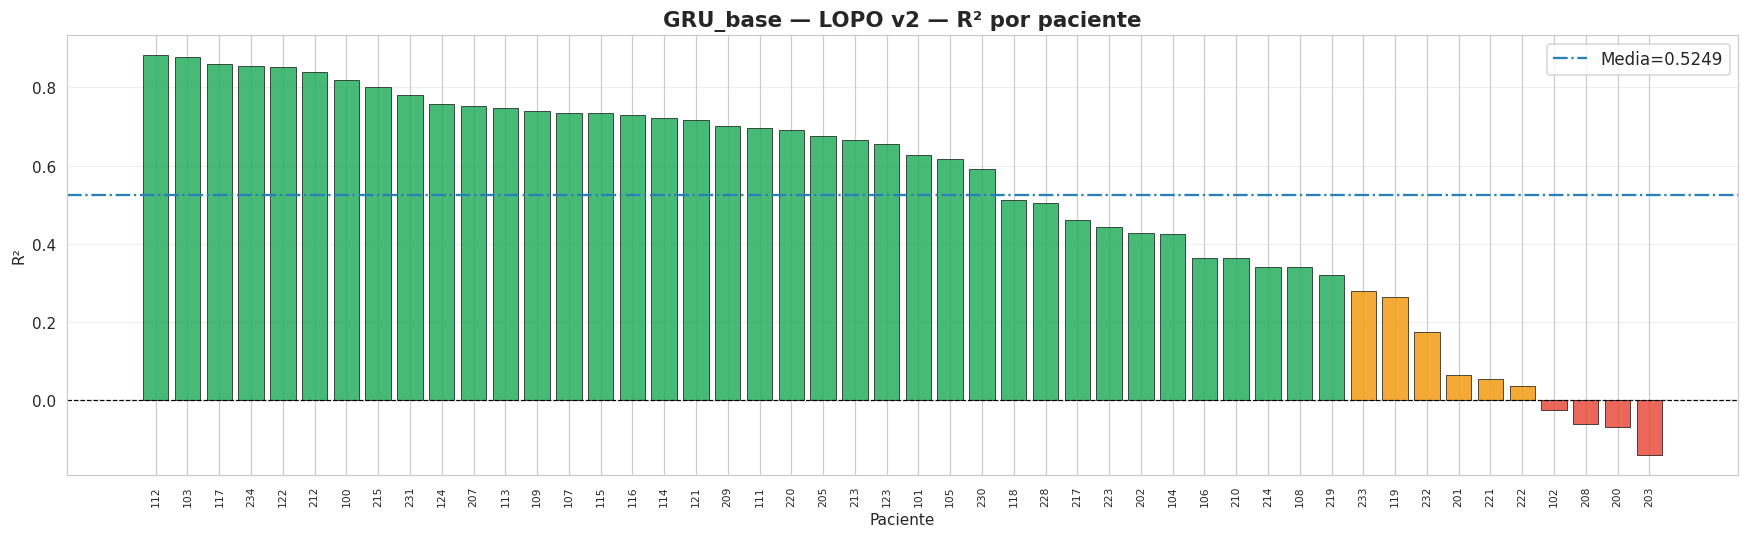

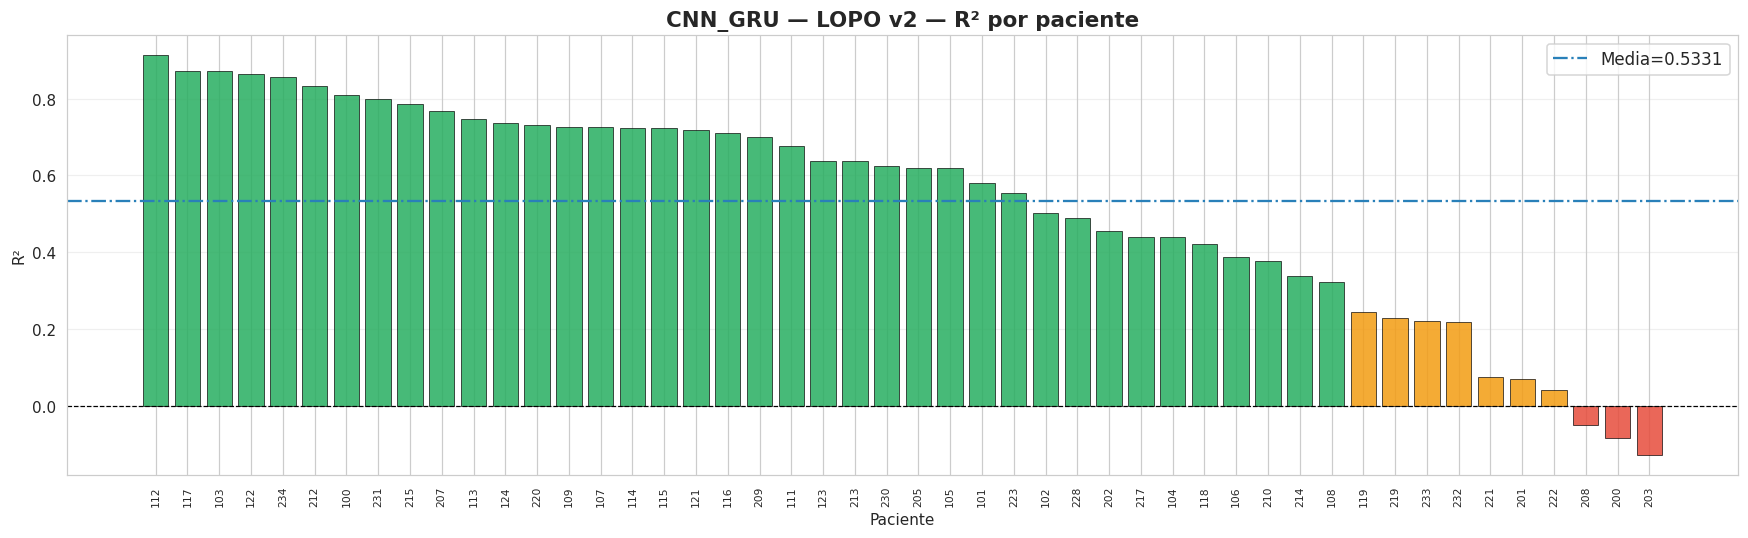

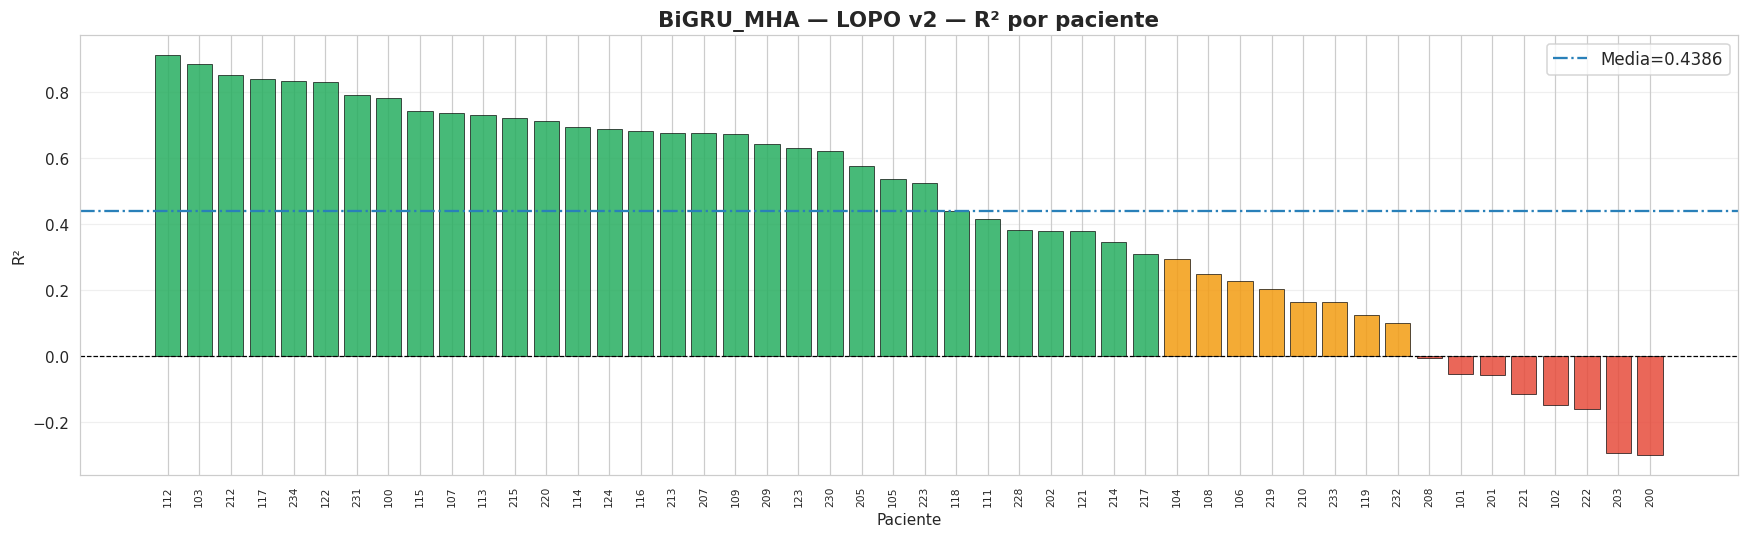

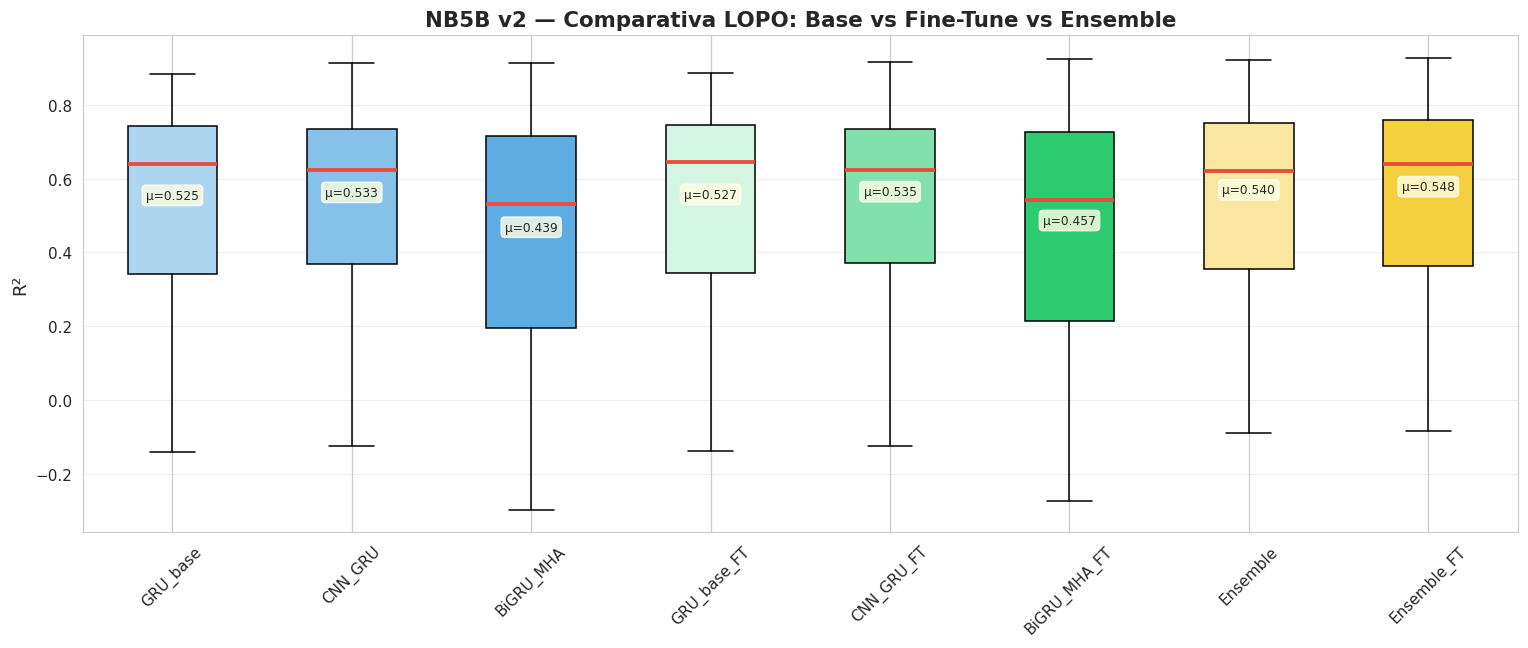

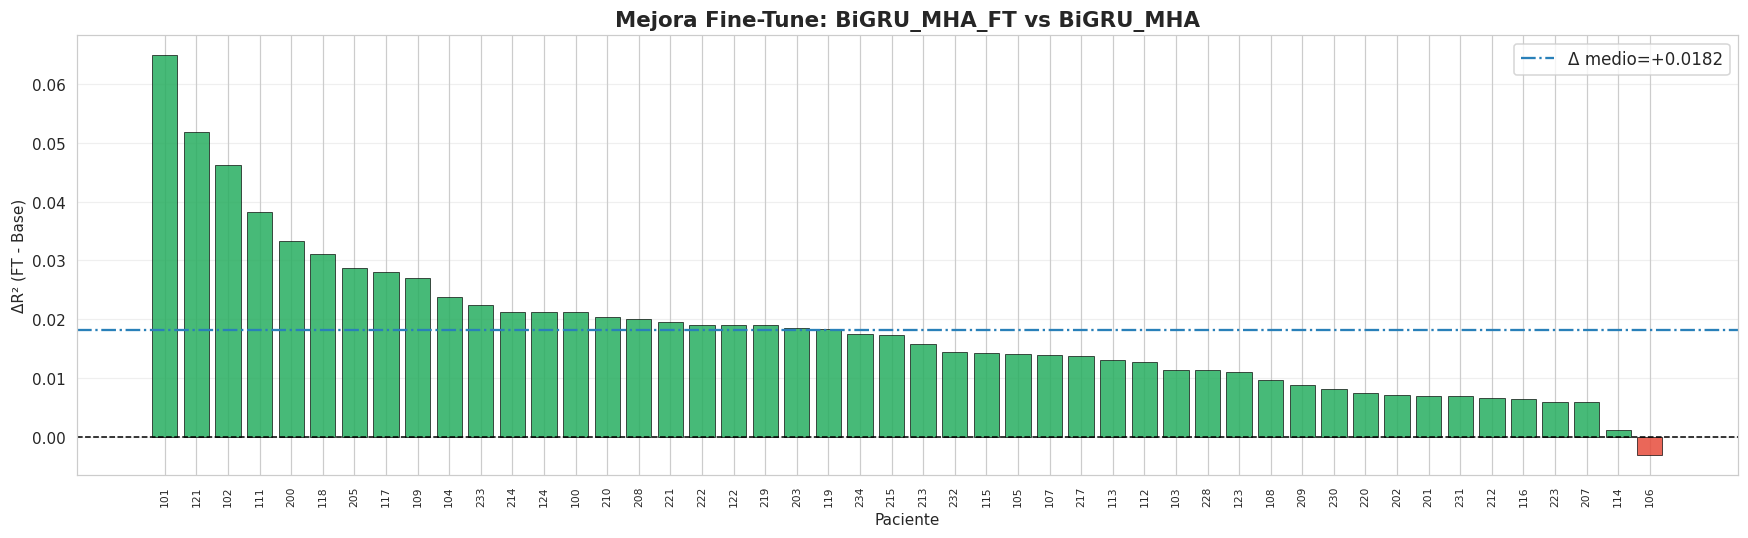

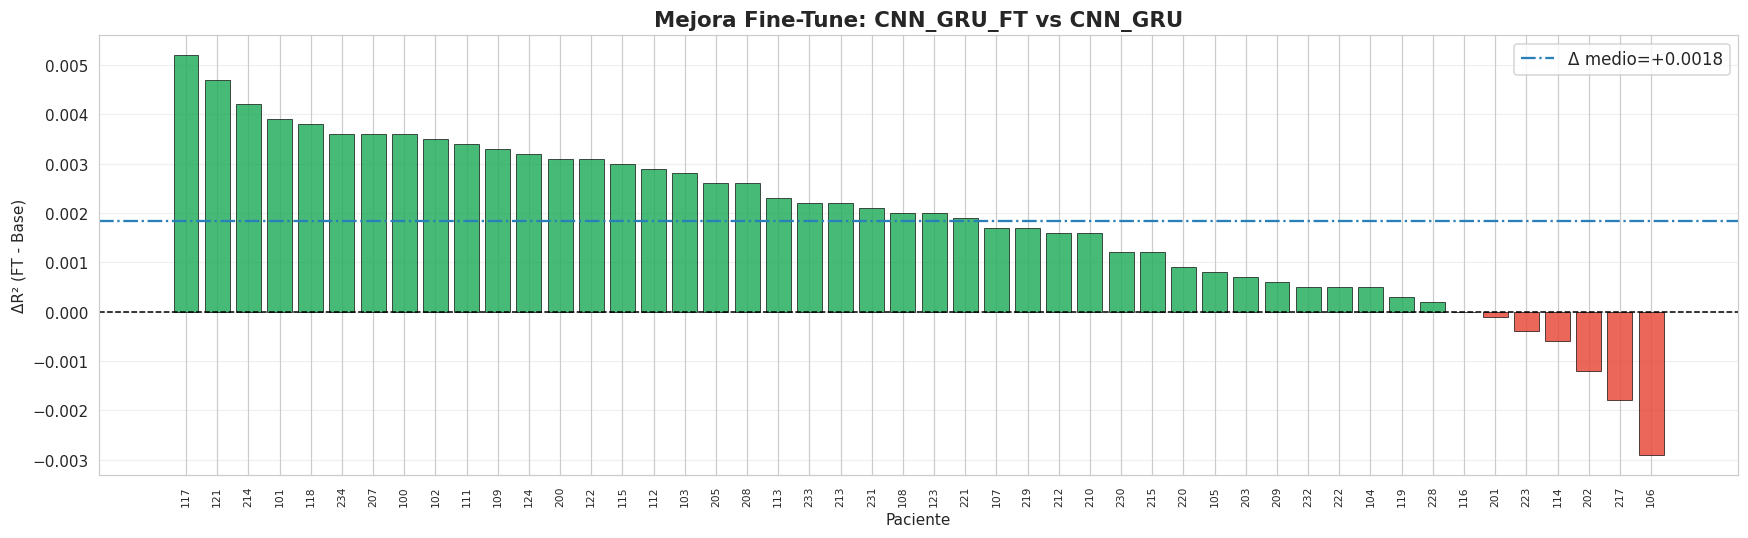

Visualizaciones guardadas.


In [ ]:
# ══════════════════════════════════════════════════════════════════
# Visualizaciones
# ══════════════════════════════════════════════════════════════════
if not df_lopo.empty and 'R2' in df_lopo.columns and len(df_lopo) > 2:

    # ── 1. Barplot R² por paciente — modelos base ────────────────
    modelos_base = ['GRU_base', 'CNN_GRU', 'BiGRU_MHA']
    for nombre_m in modelos_base:
        df_m = df_lopo[df_lopo['Modelo'] == nombre_m].sort_values('R2', ascending=False)
        if df_m.empty:
            continue

        fig, ax = plt.subplots(figsize=(16, 5))
        colors = ['#27AE60' if r > 0.3 else '#F39C12' if r > 0 else '#E74C3C'
                  for r in df_m['R2'].values]
        ax.bar(range(len(df_m)), df_m['R2'].values, color=colors,
               alpha=0.85, edgecolor='k', lw=0.5)
        ax.set_xticks(range(len(df_m)))
        ax.set_xticklabels(df_m['paciente_test'].astype(str).values,
                           rotation=90, fontsize=7)
        ax.set_xlabel('Paciente'); ax.set_ylabel('R²')
        r2_mu = df_m['R2'].mean()
        ax.axhline(0, color='k', ls='--', lw=0.8)
        ax.axhline(r2_mu, color='#2980B9', ls='-.', lw=1.5,
                   label=f'Media={r2_mu:.4f}')
        ax.set_title(f'{nombre_m} — LOPO v2 — R² por paciente',
                     fontsize=14, fontweight='bold')
        ax.legend(fontsize=11); ax.grid(axis='y', alpha=0.3)
        plt.tight_layout()
        plt.savefig(os.path.join(RUTA_VIS, f'lopo_v2_{nombre_m}_r2.png'), dpi=150)
        plt.show()

    # ── 2. Boxplot comparativo: todas las variantes ──────────────
    fig2, ax2 = plt.subplots(figsize=(14, 6))
    data_bp, labels_bp = [], []
    for m in VARIANTES:
        vals = df_lopo[df_lopo['Modelo'] == m]['R2'].dropna().values
        if len(vals) > 0:
            data_bp.append(vals)
            labels_bp.append(m)

    if data_bp:
        colors_box = ['#AED6F1', '#85C1E9', '#5DADE2',
                       '#D5F5E3', '#82E0AA', '#2ECC71',
                       '#F9E79F', '#F4D03F'][:len(data_bp)]
        bp = ax2.boxplot(data_bp, labels=labels_bp, patch_artist=True,
                         medianprops=dict(color='#E74C3C', lw=2.5))
        for patch, color in zip(bp['boxes'], colors_box):
            patch.set_facecolor(color)

        for i, d in enumerate(data_bp):
            ax2.annotate(f'μ={d.mean():.3f}', xy=(i+1, d.mean()+0.02),
                         ha='center', fontsize=8,
                         bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

        ax2.set_ylabel('R²', fontsize=12)
        ax2.set_title('NB5B v2 — Comparativa LOPO: Base vs Fine-Tune vs Ensemble',
                      fontsize=14, fontweight='bold')
        ax2.tick_params(axis='x', rotation=45)
        ax2.grid(axis='y', alpha=0.3)
        plt.tight_layout()
        plt.savefig(os.path.join(RUTA_VIS, 'lopo_v2_boxplot_all.png'), dpi=150)
        plt.show()

    # ── 3. Mejora FT vs Base por paciente ────────────────────────
    for m_base in ['BiGRU_MHA', 'CNN_GRU']:
        m_ft = f'{m_base}_FT'
        df_base = df_lopo[df_lopo['Modelo'] == m_base].set_index('paciente_test')['R2']
        df_ft   = df_lopo[df_lopo['Modelo'] == m_ft].set_index('paciente_test')['R2']

        common = df_base.index.intersection(df_ft.index)
        if len(common) < 5:
            continue

        mejora = df_ft.loc[common] - df_base.loc[common]
        mejora = mejora.sort_values(ascending=False)

        fig3, ax3 = plt.subplots(figsize=(16, 5))
        colors_m = ['#27AE60' if v > 0 else '#E74C3C' for v in mejora.values]
        ax3.bar(range(len(mejora)), mejora.values, color=colors_m,
                alpha=0.85, edgecolor='k', lw=0.5)
        ax3.set_xticks(range(len(mejora)))
        ax3.set_xticklabels(mejora.index.astype(str), rotation=90, fontsize=7)
        ax3.axhline(0, color='k', ls='--', lw=1)
        ax3.axhline(mejora.mean(), color='#2980B9', ls='-.', lw=1.5,
                     label=f'Δ medio={mejora.mean():+.4f}')
        ax3.set_xlabel('Paciente'); ax3.set_ylabel('ΔR² (FT - Base)')
        ax3.set_title(f'Mejora Fine-Tune: {m_ft} vs {m_base}',
                      fontsize=14, fontweight='bold')
        ax3.legend(fontsize=11); ax3.grid(axis='y', alpha=0.3)
        plt.tight_layout()
        plt.savefig(os.path.join(RUTA_VIS, f'lopo_v2_mejora_ft_{m_base}.png'), dpi=150)
        plt.show()

    print('Visualizaciones guardadas.')
else:
    print('Sin datos suficientes para visualizar.')

---
## BLOQUE 11 — Guardar mejor modelo .keras (para dashboard en tiempo real)

In [ ]:
# ══════════════════════════════════════════════════════════════════
# Guardar mejor modelo .keras (para dashboard en tiempo real)
# ══════════════════════════════════════════════════════════════════
if not df_lopo.empty:
    # Ranking de variantes por R² medio
    resumen = df_lopo.groupby('Modelo')['R2'].mean().sort_values(ascending=False)
    print('R² medio por variante:')
    for m, r2 in resumen.items():
        print(f'  {m:<16s} {r2:+.4f}')

    mejor_nombre = resumen.index[0]
    mejor_r2 = resumen.iloc[0]
    print(f'\nMejor variante: {mejor_nombre} (R² = {mejor_r2:.4f})')

    # Para el dashboard: reentrenar el modelo base con TODOS los pacientes
    # (FT y Ensemble se aplican en tiempo real, no se guardan como modelo)
    modelo_base = mejor_nombre.replace('_FT', '')
    if modelo_base == 'Ensemble':
        modelo_base = 'BiGRU_MHA'  # componente principal del ensemble
    build_fn = MODELOS.get(modelo_base, build_bigru_mha)

    print(f'\nReentrenando {modelo_base} con {len(REGISTROS_OK)} pacientes...')
    X_full, y_full, _, rr_mu_full, rr_std_full = construir_beatpool_v2(
        REGISTROS_OK, seed=SEED, augmentar=True
    )

    modelo_prod, hist_prod, t_prod = entrenar_modelo_v2(
        modelo_base, build_fn, X_full, y_full, verbose=1
    )

    ruta_modelo = os.path.join(RUTA_MODELOS, f'{modelo_base}_cross_patient_v2.keras')
    modelo_prod.save(ruta_modelo)
    print(f'Modelo guardado: {ruta_modelo}')

    # Metadata completa para el dashboard
    meta = {
        'modelo': modelo_base,
        'mejor_variante': mejor_nombre,
        'R2_lopo_medio': float(mejor_r2),
        'filtro': 'F_N+PB+MED',
        'lookback': N_LOOKBACK,
        'beat_len': BEAT_LEN,
        'include_rr': INCLUDE_RR,
        'feat_dim': FEAT_DIM,
        'instance_norm': True,
        'max_pares_por_paciente': MAX_PARES_POR_PACIENTE,
        'augmentation_factor': AUG_FACTOR,
        'fine_tune_k': FINE_TUNE_K,
        'fine_tune_epochs': FINE_TUNE_EPOCHS,
        'fine_tune_lr': FINE_TUNE_LR,
        'n_pacientes': len(REGISTROS_OK),
        'rr_mu_global': float(rr_mu_full),
        'rr_std_global': float(rr_std_full),
        'epochs_final': len(hist_prod.history['loss']),
        'dropout_base': DROPOUT_BASE,
        'dropout_adv': DROPOUT_ADV,
        'l2_base': L2_BASE,
        'l2_adv': L2_ADV,
    }
    ruta_meta = os.path.join(RUTA_MODELOS, f'{modelo_base}_metadata_v2.json')
    with open(ruta_meta, 'w') as f:
        json.dump(meta, f, indent=2)
    print(f'Metadata guardada: {ruta_meta}')

    # Instrucciones de uso en dashboard
    print(f'\n{"="*65}')
    print(f'  USO EN DASHBOARD (tiempo real)')
    print(f'{"="*65}')
    print(f'  1. Cargar modelo: keras.models.load_model("{ruta_modelo}")')
    print(f'  2. Cargar metadata: rr_mu={rr_mu_full:.6f}, rr_std={rr_std_full:.6f}')
    print(f'  3. Señal nueva → Filtrar (N+PB+MED) → R-peaks → Extraer latidos')
    print(f'  4. Instance Norm por latido + RR normalizado con rr_mu/rr_std')
    print(f'  5. Acumular {N_LOOKBACK} latidos → predicción')
    print(f'  6. [OPCIONAL] Fine-tune con {FINE_TUNE_K} latidos → modelo adaptado')
    print(f'{"="*65}')

    del modelo_prod, X_full, y_full
    keras.backend.clear_session(); gc.collect()
else:
    print('Sin resultados LOPO — ejecuta el bloque 8 primero.')

R² medio por variante:
  Ensemble_FT      +0.5484
  Ensemble         +0.5400
  CNN_GRU_FT       +0.5349
  CNN_GRU          +0.5331
  GRU_base_FT      +0.5272
  GRU_base         +0.5249
  BiGRU_MHA_FT     +0.4568
  BiGRU_MHA        +0.4386

Mejor variante: Ensemble_FT (R² = 0.5484)

Reentrenando BiGRU_MHA con 48 pacientes...
  Augmentation: 24,000 → 36,000 pares (+50%)
Beat-Pool v2: 36,000 pares de 48 pacientes (109,365 latidos, max 500/pac, RR=True)
Epoch 1/150
479/479 ━━━━━━━━━━━━━━━━━━━━ 17s 21ms/step - loss: 0.7301 - mae: 0.4934 - val_loss: 0.5162 - val_mae: 0.3928 - learning_rate: 3.0000e-04
Epoch 2/150
479/479 ━━━━━━━━━━━━━━━━━━━━ 9s 18ms/step - loss: 0.4986 - mae: 0.4069 - val_loss: 0.4387 - val_mae: 0.3669 - learning_rate: 3.0000e-04
Epoch 3/150
479/479 ━━━━━━━━━━━━━━━━━━━━ 10s 21ms/step - loss: 0.4424 - mae: 0.3878 - val_loss: 0.3980 - val_mae: 0.3519 - learning_rate: 3.0000e-04
Epoch 4/150
479/479 ━━━━━━━━━━━━━━━━━━━━ 10s 20ms/step - loss: 0.4088 - mae: 0.3764 - val_loss: 0.37

---
## BLOQUE 12 — Conclusiones

In [ ]:
print('='*70)
print('  CONCLUSIONES NB5B v2 — Cross-Patient Avanzado')
print('='*70)
print(f"""
  Estrategia: Beat-Pool v2 con mejoras integrales

  Mejoras implementadas:
   Instance Normalization por latido (no z-score por paciente)
   Intervalos RR como feature auxiliar (dim={FEAT_DIM})
   Max {MAX_PARES_POR_PACIENTE} pares/paciente + Augmentation {AUG_FACTOR:.0%}
   3 arquitecturas: GRU_base, CNN-GRU, BiGRU-MHA
   Fine-tuning: K={FINE_TUNE_K} latidos, {FINE_TUNE_EPOCHS} epochs, lr={FINE_TUNE_LR}
   Ensemble: promedio CNN-GRU + BiGRU-MHA
   Regularización: L2_adv={L2_ADV}, SpatialDropout, Dropout_adv={DROPOUT_ADV}

  Evaluación: LOPO (Leave-One-Patient-Out)
  - {len(VARIANTES)} variantes × {len(TODOS_LOS_PACIENTES)} pacientes
  - Métricas: R², MSE, RMSE, MAE, DTW, Latencia, R²_train
""")

print('  Archivos generados:')
for f in ['resultados_lopo_v2.csv', 'tabla_resumen_v2.csv',
          'lopo_v2_checkpoint.csv']:
    ruta = os.path.join(RUTA_RESULTS, f)
    e = '' if os.path.exists(ruta) else ''
    print(f'    {e} {f}')

if os.path.isdir(RUTA_VIS):
    for f in sorted(os.listdir(RUTA_VIS)):
        if 'v2' in f:
            print(f'     visualizaciones/{f}')

if os.path.isdir(RUTA_MODELOS):
    for f in sorted(os.listdir(RUTA_MODELOS)):
        if f.endswith(('.keras', '.json')) and 'v2' in f:
            print(f'     modelos/{f}')

print(f"""
  Dashboard de producción:
  → Cargar modelo .keras + metadata .json
  → Señal ECG → Filtrar → R-peaks → Instance Norm → RR
  → Fine-tune con K={FINE_TUNE_K} latidos → Predecir en tiempo real
""")
print('='*70)

---
## BLOQUE 13 — Mejoras al GRU Ganador: Loss Ponderado + Fine-Tuning Agresivo

**Motivación:** Los pacientes con arritmias severas (201, 203, 221, 222) tienen R² < 0.15
El modelo aprende mayoritariamente latidos normales (~85%) y subpondera las transiciones arrítmicas.

**Mejoras:**
1. **Loss ponderado:** Secuencias cuyo latido objetivo es arrítmico (PVC, APC, etc.) reciben peso 3× en MSE.
2. **Oversampling dirigido:** Secuencias arrítmicas se sobremuestrean 2× en el beat-pool.
3. **Fine-tuning agresivo:** Descongela última capa GRU + Dense, K=50 latidos, 15 épocas, lr=5e-5.

**Evaluación:** LOPO completo (48 pacientes) con GRU_weighted + GRU_weighted_FT.

In [8]:
# ══════════════════════════════════════════════════════════════════
# BLOQUE 13a — Config + Helpers para mejoras GRU
# ══════════════════════════════════════════════════════════════════

W_ARRITMIA       = 3.0
OVERSAMPLE_ARR   = 2.0
K_FT_AGR         = 50
EPOCHS_FT_AGR    = 15
LR_FT_AGR        = 5e-5
TIPOS_ARRITMICOS = set('VFaAJjSEe')

# --- Cargar anotaciones MIT-BIH ---
print('Cargando anotaciones beat-by-beat...')
ANNS = {}
for pid in REGISTROS_OK:
    try:
        ANNS[pid] = wfdb.rdann(os.path.join(RUTA_DATOS, pid), 'atr')
    except Exception:
        ANNS[pid] = None
print(f'Anotaciones: {sum(1 for v in ANNS.values() if v is not None)}/{len(REGISTROS_OK)}')


def extraer_latidos_anotado(senal, rpeaks, ann, beat_len=BEAT_LEN):
    sym_map = {}
    if ann is not None:
        for samp, sym in zip(ann.sample, ann.symbol):
            if sym in BEAT_TYPES:
                sym_map[int(samp)] = sym

    beats, rr_vals, btypes = [], [], []
    for i in range(1, len(rpeaks) - 1):
        start = (rpeaks[i-1] + rpeaks[i]) // 2
        end   = (rpeaks[i]   + rpeaks[i+1]) // 2
        seg   = senal[start:end]
        if len(seg) < 50:
            continue
        beat = spsig.resample(seg, beat_len).astype(np.float32)
        mu_b  = float(beat.mean())
        std_b = max(float(beat.std()), 1e-8)
        beats.append((beat - mu_b) / std_b)
        rr_vals.append((rpeaks[i+1] - rpeaks[i]) / FS)
        btypes.append(sym_map.get(int(rpeaks[i]), 'N'))

    if beats:
        return np.array(beats, np.float32), np.array(rr_vals, np.float32), btypes
    return np.empty((0, beat_len), np.float32), np.array([], np.float32), []


def secuencias_con_pesos(beats, rr, btypes, n_lb=N_LOOKBACK):
    fd = BEAT_LEN + 1 if INCLUDE_RR else BEAT_LEN
    if len(beats) <= n_lb:
        return (np.empty((0, n_lb, fd), np.float32),
                np.empty((0, BEAT_LEN), np.float32),
                np.array([], np.float32))

    X_list, y_list, w_list = [], [], []
    for i in range(n_lb, len(beats)):
        window = beats[i - n_lb : i]
        if INCLUDE_RR and len(rr) >= len(beats):
            rr_col = rr[i - n_lb : i].reshape(-1, 1).astype(np.float32)
            window = np.concatenate([window, rr_col], axis=1)
        elif INCLUDE_RR:
            window = np.concatenate([window, np.zeros((n_lb, 1), np.float32)], axis=1)

        X_list.append(window)
        y_list.append(beats[i])
        w = W_ARRITMIA if (i < len(btypes) and btypes[i] in TIPOS_ARRITMICOS) else 1.0
        w_list.append(w)

    return (np.array(X_list, np.float32),
            np.array(y_list, np.float32),
            np.array(w_list, np.float32))


def construir_beatpool_weighted(lista_pac, max_pares=MAX_PARES_POR_PACIENTE, seed=42):
    rng_bp = np.random.default_rng(seed)
    X_all, y_all, w_all = [], [], []

    for pid in lista_pac:
        if pid not in DATOS or pid not in ANNS:
            continue
        beats, rr, btypes = extraer_latidos_anotado(DATOS[pid], RPEAKS[pid], ANNS[pid])
        if len(beats) < N_LOOKBACK + 2:
            continue
        X_p, y_p, w_p = secuencias_con_pesos(beats, rr, btypes)
        if len(X_p) == 0:
            continue

        arr_mask = w_p > 1.0
        n_arr = int(arr_mask.sum())
        if n_arr > 0:
            n_extra = int(n_arr * (OVERSAMPLE_ARR - 1))
            if n_extra > 0:
                idx_arr = np.where(arr_mask)[0]
                idx_over = rng_bp.choice(idx_arr, min(n_extra, len(idx_arr) * 3), replace=True)
                X_p = np.concatenate([X_p, X_p[idx_over]])
                y_p = np.concatenate([y_p, y_p[idx_over]])
                w_p = np.concatenate([w_p, w_p[idx_over]])

        if len(X_p) > max_pares:
            idx = rng_bp.choice(len(X_p), max_pares, replace=False)
            X_p, y_p, w_p = X_p[idx], y_p[idx], w_p[idx]

        X_all.append(X_p); y_all.append(y_p); w_all.append(w_p)

    X = np.concatenate(X_all)
    y = np.concatenate(y_all)
    w = np.concatenate(w_all)

    n_pre = len(X)
    X, y = augmentar_beatpool(X, y, rng_bp, factor=AUG_FACTOR)
    if len(X) > n_pre:
        w = np.concatenate([w, np.ones(len(X) - n_pre, dtype=np.float32)])

    rr_mu  = float(X[:, :, BEAT_LEN].mean())
    rr_std = max(float(X[:, :, BEAT_LEN].std()), 1e-8)
    X[:, :, BEAT_LEN] = (X[:, :, BEAT_LEN] - rr_mu) / rr_std

    idx = rng_bp.permutation(len(X))
    X, y, w = X[idx], y[idx], w[idx]

    n_arr_total = int((w > 1).sum())
    print(f'Beat-Pool weighted: {len(X):,} pares | '
          f'{n_arr_total} arritmicos ({n_arr_total/len(X)*100:.1f}%)')
    return X, y, w, rr_mu, rr_std


def entrenar_gru_weighted(X_tr, y_tr, w_tr, verbose=0):
    input_shape = X_tr.shape[1:]
    modelo = build_gru_base(input_shape, BEAT_LEN)
    modelo.compile(optimizer=keras.optimizers.Adam(LR_BASE), loss='mse', metrics=['mae'])

    cbs = [
        callbacks.EarlyStopping(monitor='val_loss', patience=PAT_ES_BASE,
                                restore_best_weights=True),
        callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                                    patience=max(PAT_ES_BASE // 3, 3), min_lr=1e-6),
    ]

    t0 = time.perf_counter()
    hist = modelo.fit(X_tr, y_tr, sample_weight=w_tr,
                      epochs=EPOCHS_BASE, batch_size=BATCH_BASE,
                      validation_split=0.15, callbacks=cbs, verbose=verbose)
    t_train = time.perf_counter() - t0
    return modelo, hist, t_train


def finetune_agresivo(modelo, X_ft, y_ft):
    modelo_ft = tf.keras.models.clone_model(modelo)
    modelo_ft.set_weights(modelo.get_weights())

    for layer in modelo_ft.layers:
        layer.trainable = False

    gru_layers = [l for l in modelo_ft.layers if 'gru' in l.name.lower()]
    if gru_layers:
        gru_layers[-1].trainable = True
    for layer in modelo_ft.layers:
        if isinstance(layer, layers.Dense):
            layer.trainable = True

    modelo_ft.compile(optimizer=keras.optimizers.Adam(LR_FT_AGR), loss='mse')
    modelo_ft.fit(X_ft, y_ft, epochs=EPOCHS_FT_AGR,
                  batch_size=min(32, max(1, len(X_ft))), verbose=0)
    return modelo_ft


print(f'Helpers definidos: W_arritmia={W_ARRITMIA}, K_FT={K_FT_AGR}, '
      f'Oversample={OVERSAMPLE_ARR}x, FT_epochs={EPOCHS_FT_AGR}')

Cargando anotaciones beat-by-beat...
Anotaciones: 48/48
Helpers definidos: W_arritmia=3.0, K_FT=50, Oversample=2.0x, FT_epochs=15


In [9]:
# ══════════════════════════════════════════════════════════════════
# BLOQUE 13b — LOPO: GRU con Loss Ponderado + Fine-Tuning Agresivo
# ══════════════════════════════════════════════════════════════════

RUTA_CKP_W = os.path.join(RUTA_RESULTS, 'lopo_weighted_checkpoint.csv')
RUTA_CSV_W = os.path.join(RUTA_RESULTS, 'resultados_lopo_weighted.csv')

filas_w = []
pacs_w_completos = set()

if os.path.exists(RUTA_CKP_W):
    df_ckp_w = pd.read_csv(RUTA_CKP_W)
    df_ckp_w['paciente_test'] = df_ckp_w['paciente_test'].astype(str)
    filas_w = df_ckp_w.to_dict('records')
    for pid in df_ckp_w['paciente_test'].unique():
        mods = set(df_ckp_w[df_ckp_w['paciente_test'] == pid]['Modelo'].values)
        if 'GRU_weighted' in mods:
            pacs_w_completos.add(pid)
    print(f'Checkpoint weighted: {len(filas_w)} filas | {len(pacs_w_completos)} pacientes.')
else:
    print('Sin checkpoint weighted. Iniciando desde cero.')

t0_w = time.perf_counter()
n_total_w = len(REGISTROS_OK)
n_done_w = len(pacs_w_completos)

print(f'\n{"="*70}')
print(f'  LOPO GRU Weighted - {n_total_w} pacientes')
print(f'  Completados: {n_done_w} | Pendientes: {n_total_w - n_done_w}')
print(f'  W_arritmia={W_ARRITMIA} | Oversample={OVERSAMPLE_ARR}x')
print(f'  FT agresivo: K={K_FT_AGR}, epochs={EPOCHS_FT_AGR}, lr={LR_FT_AGR}')
print(f'{"="*70}')

for ip, p_test in enumerate(REGISTROS_OK):
    if p_test in pacs_w_completos:
        continue

    p_train = [p for p in REGISTROS_OK if p != p_test]

    try:
        X_tr, y_tr, w_tr, rr_mu, rr_std = construir_beatpool_weighted(
            p_train, max_pares=MAX_PARES_POR_PACIENTE,
            seed=SEED + int(p_test)
        )
    except Exception as e:
        print(f'  [{p_test}] Error beat-pool: {e}'); continue

    if len(X_tr) < 50:
        print(f'  [{p_test}] Muy pocos pares'); continue

    try:
        X_te, y_te = cargar_test_v2(p_test, rr_mu, rr_std)
    except Exception as e:
        print(f'  [{p_test}] Error test: {e}')
        del X_tr, y_tr, w_tr; gc.collect(); continue

    if len(X_te) < 5:
        del X_tr, y_tr, w_tr, X_te, y_te; gc.collect(); continue

    n_ft = min(K_FT_AGR - N_LOOKBACK, len(X_te) // 3)
    puede_ft = n_ft >= 3
    X_ft   = X_te[:n_ft]  if puede_ft else None
    y_ft   = y_te[:n_ft]  if puede_ft else None
    X_eval = X_te[n_ft:]  if puede_ft else X_te
    y_eval = y_te[n_ft:]  if puede_ft else y_te

    n_actual = ip + 1
    print(f'\n[{n_actual:02d}/{n_total_w}] Test={p_test}')
    tf.random.set_seed(SEED)

    try:
        modelo, hist, t_train = entrenar_gru_weighted(X_tr, y_tr, w_tr)
    except Exception as e:
        print(f'  Error entrenamiento: {e}')
        keras.backend.clear_session(); gc.collect(); continue

    met_base, yp_te = evaluar_modelo(modelo, X_te, y_te, X_tr, y_tr)
    if met_base is None:
        del modelo; keras.backend.clear_session(); gc.collect(); continue

    filas_pac = []
    fila_base = {
        'paciente_test': p_test, 'Modelo': 'GRU_weighted',
        'Filtro': 'F_N+PB+MED', 'Lookback': N_LOOKBACK,
        'n_pac_train': len(p_train), 'n_train': len(X_tr),
        'n_test': len(X_te), 'n_ft': 0,
        't_fit_s': round(t_train, 2),
        'epochs_ran': len(hist.history['loss']),
        **met_base
    }
    filas_pac.append(fila_base)
    print(f'  WEIGHTED:    R2_tr={met_base.get("R2_train","?"):+.4f} | '
          f'R2_te={met_base["R2"]:+.4f} | RMSE={met_base["RMSE"]:.4f} | {t_train:.0f}s')

    if puede_ft:
        try:
            modelo_ft = finetune_agresivo(modelo, X_ft, y_ft)
            met_ft, yp_eval = evaluar_modelo(modelo_ft, X_eval, y_eval)
            if met_ft:
                fila_ft = {
                    'paciente_test': p_test, 'Modelo': 'GRU_weighted_FT',
                    'Filtro': 'F_N+PB+MED', 'Lookback': N_LOOKBACK,
                    'n_pac_train': len(p_train), 'n_train': len(X_tr),
                    'n_test': len(X_eval), 'n_ft': n_ft,
                    't_fit_s': round(t_train, 2),
                    'epochs_ran': len(hist.history['loss']),
                    **met_ft
                }
                filas_pac.append(fila_ft)
                print(f'  WEIGHTED_FT: R2_eval={met_ft["R2"]:+.4f} | RMSE={met_ft["RMSE"]:.4f}')
            del modelo_ft
        except Exception as e:
            print(f'  FT error: {e}')

    if len(filas_pac) < 2:
        fb = fila_base.copy()
        fb['Modelo'] = 'GRU_weighted_FT'
        filas_pac.append(fb)

    filas_w = [f for f in filas_w if str(f.get('paciente_test')) != p_test]
    filas_w.extend(filas_pac)
    pacs_w_completos.add(p_test)
    pd.DataFrame(filas_w).to_csv(RUTA_CKP_W, index=False)

    del modelo, X_tr, y_tr, w_tr, X_te, y_te
    if puede_ft:
        del X_ft, y_ft, X_eval, y_eval
    keras.backend.clear_session(); gc.collect()
    print(f'  [{p_test}] OK | RAM: {psutil.virtual_memory().available/1e9:.1f} GB')

df_weighted = pd.DataFrame(filas_w)
df_weighted.to_csv(RUTA_CSV_W, index=False)

t_min_w = (time.perf_counter() - t0_w) / 60
print(f'\n{"="*70}')
print(f'  LOPO GRU Weighted COMPLETADO - {t_min_w:.1f} min')
for m in ['GRU_weighted', 'GRU_weighted_FT']:
    sub = df_weighted[df_weighted.Modelo == m]
    if not sub.empty:
        print(f'  {m:20s}  R2 = {sub.R2.mean():+.4f} +/- {sub.R2.std():.4f}')
print(f'{"="*70}')

Checkpoint weighted: 96 filas | 48 pacientes.

  LOPO GRU Weighted - 48 pacientes
  Completados: 48 | Pendientes: 0
  W_arritmia=3.0 | Oversample=2.0x
  FT agresivo: K=50, epochs=15, lr=5e-05

  LOPO GRU Weighted COMPLETADO - 0.0 min
  GRU_weighted          R2 = +0.5311 +/- 0.2920
  GRU_weighted_FT       R2 = +0.5630 +/- 0.2924


---
## BLOQUE 14 — Validación Externa: INCART Database (St. Petersburg)

Evaluación del modelo GRU en una base de datos **completamente independiente**.

| Aspecto | MIT-BIH | INCART |
|---------|---------|--------|
| Origen | Beth Israel Hospital, Boston | St. Petersburg Institute, Rusia |
| Pacientes | 48 | 75 |
| Duración | 30 min c/u | 30 min c/u |
| Frecuencia | 360 Hz | 257 Hz |
| Derivaciones | 2 | 12 |

El modelo fue **entrenado solo con MIT-BIH**. Si funciona en INCART, demuestra generalización real.

In [10]:
# ══════════════════════════════════════════════════════════════════
# BLOQUE 14 — Validación Externa: INCART
# ══════════════════════════════════════════════════════════════════

FS_INCART = 257
RUTA_INCART = os.path.join(os.path.dirname(RUTA_DATOS), 'incart')
os.makedirs(RUTA_INCART, exist_ok=True)
RUTA_INC_CSV = os.path.join(RUTA_RESULTS, 'validacion_incart.csv')

if os.path.exists(RUTA_INC_CSV):
    df_incart = pd.read_csv(RUTA_INC_CSV)
    print(f'INCART ya evaluado ({len(df_incart)} registros). Cargando CSV.')
else:
    # --- 1. Descargar INCART ---
    print('Descargando INCART database...')
    INCART_RECORDS = [f'I{i:02d}' for i in range(1, 76)]
    descargados = 0
    for rec in INCART_RECORDS:
        hea_path = os.path.join(RUTA_INCART, rec + '.hea')
        if os.path.exists(hea_path):
            descargados += 1; continue
        try:
            wfdb.dl_files('incartdb', RUTA_INCART,
                          [rec + ext for ext in ['.dat', '.hea', '.atr']])
            descargados += 1
        except Exception as e:
            print(f'  X {rec}: {e}')
    print(f'Registros disponibles: {descargados}/{len(INCART_RECORDS)}')

    if descargados == 0:
        print('ERROR: No se pudo descargar ningun registro INCART. Abortando.')
        df_incart = pd.DataFrame()
    else:
        # --- 2. Filtrado adaptado a 257 Hz ---
        def filtro_incart(senal):
            ny = FS_INCART / 2.0
            b, a = spsig.iirnotch(FREC_NOTCH, Q_NOTCH, FS_INCART)
            s = spsig.filtfilt(b, a, senal)
            b, a = spsig.butter(ORDEN_BUT, [F_BAJO / ny, min(F_ALTO / ny, 0.99)], btype='band')
            s = spsig.filtfilt(b, a, s)
            k = FS_INCART // 10; k = k if k % 2 == 1 else k + 1
            s = median_filter(s, size=k)
            return s.astype(np.float32)

        def cargar_incart_registro(rec, rr_mu_g, rr_std_g):
            ruta = os.path.join(RUTA_INCART, rec)
            try:
                record = wfdb.rdrecord(ruta)
            except Exception:
                return None, None
            senal = record.p_signal[:, 0].astype(np.float32)
            senal_f = filtro_incart(senal)
            try:
                ann = wfdb.rdann(ruta, 'atr')
                rpeaks = np.array([s for s, sym in zip(ann.sample, ann.symbol)
                                   if sym in BEAT_TYPES], dtype=np.int64)
            except Exception:
                return None, None
            if len(rpeaks) < N_LOOKBACK + 5:
                return None, None

            beats, rr_vals = [], []
            for i in range(1, len(rpeaks) - 1):
                start = (rpeaks[i-1] + rpeaks[i]) // 2
                end   = (rpeaks[i]   + rpeaks[i+1]) // 2
                seg   = senal_f[start:end]
                if len(seg) < 50:
                    continue
                beat = spsig.resample(seg, BEAT_LEN).astype(np.float32)
                mu_b  = float(beat.mean())
                std_b = max(float(beat.std()), 1e-8)
                beats.append((beat - mu_b) / std_b)
                rr_vals.append((rpeaks[i+1] - rpeaks[i]) / FS_INCART)

            if len(beats) < N_LOOKBACK + 2:
                return None, None

            beats = np.array(beats, dtype=np.float32)
            rr_vals = np.array(rr_vals, dtype=np.float32)
            X, y = secuencias_con_rr(beats, rr_vals)
            if INCLUDE_RR and X.shape[-1] > BEAT_LEN:
                X[:, :, BEAT_LEN] = (X[:, :, BEAT_LEN] - rr_mu_g) / rr_std_g
            return X, y

        # --- 3. Entrenar modelo produccion con todos los MIT-BIH ---
        print('\nEntrenando GRU produccion (48 pacientes MIT-BIH)...')
        X_prod, y_prod, _, rr_mu_prod, rr_std_prod = construir_beatpool_v2(
            REGISTROS_OK, seed=SEED, augmentar=True
        )
        tf.random.set_seed(SEED)
        modelo_prod, hist_prod, t_prod = entrenar_modelo_v2(
            'GRU_base', build_gru_base, X_prod, y_prod, verbose=1
        )
        print(f'Modelo produccion: {len(hist_prod.history["loss"])} epochs, {t_prod:.0f}s')
        del X_prod, y_prod; gc.collect()

        # --- 4. Evaluar en INCART ---
        print(f'\nEvaluando en INCART...')
        resultados_incart = []
        for rec in INCART_RECORDS:
            if not os.path.exists(os.path.join(RUTA_INCART, rec + '.hea')):
                continue
            X_inc, y_inc = cargar_incart_registro(rec, rr_mu_prod, rr_std_prod)
            if X_inc is None or len(X_inc) < 5:
                continue
            t0_i = time.perf_counter()
            yp = modelo_prod.predict(X_inc, verbose=0)
            lat = (time.perf_counter() - t0_i) / max(len(X_inc), 1) * 1000
            met = calcular_metricas(y_inc, yp, lat)
            if met:
                met['registro'] = rec
                met['n_test'] = len(X_inc)
                resultados_incart.append(met)
                print(f'  {rec}: R2={met["R2"]:+.4f} | RMSE={met["RMSE"]:.4f} | n={len(X_inc)}')

        df_incart = pd.DataFrame(resultados_incart)
        df_incart.to_csv(RUTA_INC_CSV, index=False)
        del modelo_prod; keras.backend.clear_session(); gc.collect()

if not df_incart.empty:
    r2v = df_incart['R2']
    pos = int((r2v > 0).sum())
    gt05 = int((r2v > 0.5).sum())
    print(f'\n{"="*65}')
    print(f'  INCART - Validacion Externa ({len(df_incart)} registros)')
    print(f'  R2 medio   = {r2v.mean():+.4f} +/- {r2v.std():.4f}')
    print(f'  R2 mediana  = {r2v.median():+.4f}')
    print(f'  R2 > 0  : {pos}/{len(df_incart)} ({pos/len(df_incart)*100:.0f}%)')
    print(f'  R2 > 0.5: {gt05}/{len(df_incart)} ({gt05/len(df_incart)*100:.0f}%)')
    print(f'{"="*65}')
else:
    print('No se pudieron evaluar registros INCART.')

Descargando INCART database...
Finished downloading files
Finished downloading files
Finished downloading files
Finished downloading files
Finished downloading files
Finished downloading files
Finished downloading files
Finished downloading files
Finished downloading files
Finished downloading files
Finished downloading files
Finished downloading files
Finished downloading files
Finished downloading files
Finished downloading files
Finished downloading files
Finished downloading files
Finished downloading files
Finished downloading files
Finished downloading files
Finished downloading files
Finished downloading files
Finished downloading files
Finished downloading files
Finished downloading files
Finished downloading files
Finished downloading files
Finished downloading files
Finished downloading files
Finished downloading files
Finished downloading files
Finished downloading files
Finished downloading files
Finished downloading files
Finished downloading files
Finished downloading fil

  COMPARATIVA FINAL
  Modelo                   R2 medio    +/- Std    Mediana     R2>0   R2>0.5
--------------------------------------------------------------------------------
  GRU_base                  +0.5249     0.2938    +0.6408    44/48    29/48
  GRU_base_FT               +0.5272     0.2942    +0.6441    44/48    29/48
  Ensemble_FT               +0.5484     0.2724    +0.6387    46/48    28/48
  GRU_weighted              +0.5311     0.2920    +0.6429    45/48    29/48
  GRU_weighted_FT           +0.5630     0.2924    +0.6661    45/48    29/48
  INCART (externo)          +0.3764     0.2663    +0.3598    70/75     26/75
--------------------------------------------------------------------------------

  PACIENTES DIFICILES: 201, 203, 221, 222
  Modelo                    Pac 201    Pac 203    Pac 221    Pac 222      Media
--------------------------------------------------------------------------------
  GRU_base                  +0.0622    -0.1406    +0.0520    +0.0356    +0.0023
 

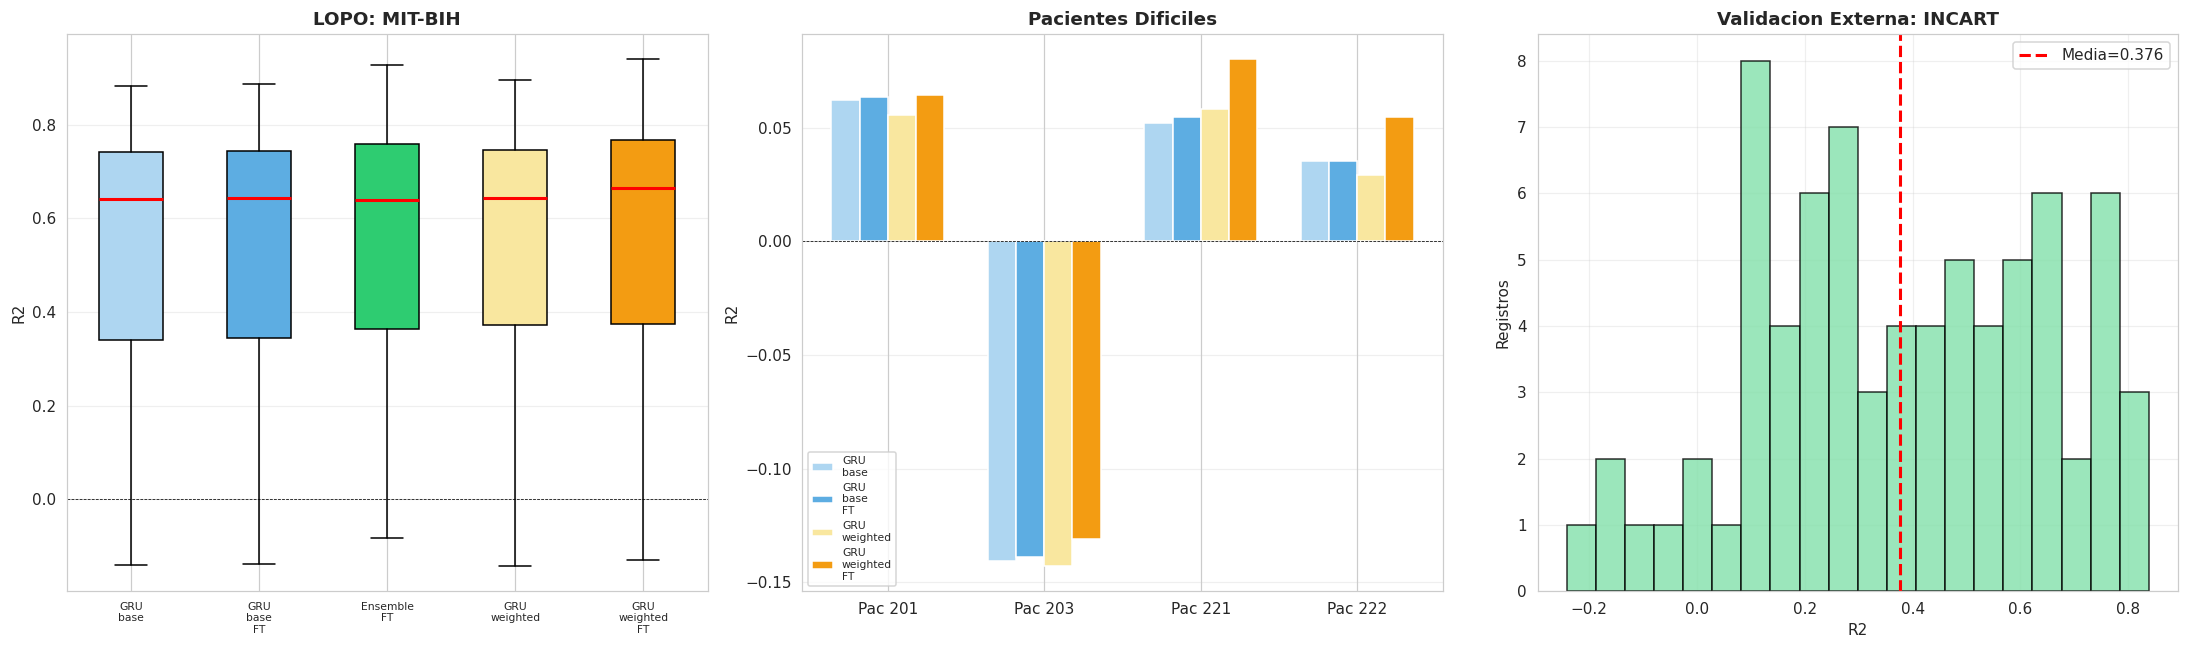


Entrenando modelo GRU_weighted produccion (48 pacientes)...
Beat-Pool weighted: 36,000 pares | 3676 arritmicos (10.2%)
Epoch 1/100
957/957 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - loss: 0.6414 - mae: 0.4661 - val_loss: 0.5132 - val_mae: 0.3812 - learning_rate: 0.0010
Epoch 2/100
957/957 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - loss: 0.5313 - mae: 0.4138 - val_loss: 0.4754 - val_mae: 0.3662 - learning_rate: 0.0010
Epoch 3/100
957/957 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - loss: 0.4997 - mae: 0.4016 - val_loss: 0.4537 - val_mae: 0.3555 - learning_rate: 0.0010
Epoch 4/100
957/957 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - loss: 0.4786 - mae: 0.3941 - val_loss: 0.4416 - val_mae: 0.3491 - learning_rate: 0.0010
Epoch 5/100
957/957 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - loss: 0.4637 - mae: 0.3889 - val_loss: 0.4329 - val_mae: 0.3444 - learning_rate: 0.0010
Epoch 6/100
957/957 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - loss: 0.4539 - mae: 0.3851 - val_loss: 0.4301 - val_mae: 0.3420 - learning_rate: 0.0010
Epoch 7/100
957/957 ━

In [11]:
# ══════════════════════════════════════════════════════════════════
# BLOQUE 15 — Comparativa Final + Guardar Artefactos
# ══════════════════════════════════════════════════════════════════

df_v2 = pd.read_csv(os.path.join(RUTA_RESULTS, 'resultados_lopo_v2.csv'))
df_v2['paciente_test'] = df_v2['paciente_test'].astype(str)

ruta_w = os.path.join(RUTA_RESULTS, 'resultados_lopo_weighted.csv')
df_w = pd.read_csv(ruta_w) if os.path.exists(ruta_w) else pd.DataFrame()
if not df_w.empty:
    df_w['paciente_test'] = df_w['paciente_test'].astype(str)

ruta_inc = os.path.join(RUTA_RESULTS, 'validacion_incart.csv')
df_inc = pd.read_csv(ruta_inc) if os.path.exists(ruta_inc) else pd.DataFrame()

# --- 1. Tabla resumen ---
print('='*80)
print('  COMPARATIVA FINAL')
print('='*80)
print(f'  {"Modelo":<22s} {"R2 medio":>10s} {"+/- Std":>10s} {"Mediana":>10s} {"R2>0":>8s} {"R2>0.5":>8s}')
print('-'*80)

for m in ['GRU_base', 'GRU_base_FT', 'Ensemble_FT']:
    sub = df_v2[df_v2.Modelo == m]
    if sub.empty:
        continue
    r2 = sub.R2
    print(f'  {m:<22s} {r2.mean():+10.4f} {r2.std():10.4f} {r2.median():+10.4f} '
          f'{int((r2>0).sum()):>5d}/48 {int((r2>0.5).sum()):>5d}/48')

if not df_w.empty:
    for m in ['GRU_weighted', 'GRU_weighted_FT']:
        sub = df_w[df_w.Modelo == m]
        if sub.empty:
            continue
        r2 = sub.R2
        print(f'  {m:<22s} {r2.mean():+10.4f} {r2.std():10.4f} {r2.median():+10.4f} '
              f'{int((r2>0).sum()):>5d}/48 {int((r2>0.5).sum()):>5d}/48')

if not df_inc.empty:
    r2 = df_inc.R2
    n = len(df_inc)
    print(f'  {"INCART (externo)":<22s} {r2.mean():+10.4f} {r2.std():10.4f} {r2.median():+10.4f} '
          f'{int((r2>0).sum()):>5d}/{n}  {int((r2>0.5).sum()):>5d}/{n}')
print('-'*80)

# --- 2. Pacientes dificiles ---
DIFICILES = ['201', '203', '221', '222']
print(f'\n{"="*80}')
print(f'  PACIENTES DIFICILES: {", ".join(DIFICILES)}')
print(f'{"="*80}')
print(f'  {"Modelo":<22s}', end='')
for pid in DIFICILES:
    print(f' {"Pac "+pid:>10s}', end='')
print(f' {"Media":>10s}')
print('-'*80)

modelos_dif = ['GRU_base', 'GRU_base_FT', 'Ensemble_FT']
if not df_w.empty:
    modelos_dif += ['GRU_weighted', 'GRU_weighted_FT']

for m in modelos_dif:
    src = df_w if 'weighted' in m else df_v2
    if src.empty:
        continue
    vals = []
    print(f'  {m:<22s}', end='')
    for pid in DIFICILES:
        sub = src[(src.Modelo == m) & (src.paciente_test == pid)]
        r2 = sub.R2.values[0] if len(sub) > 0 else float('nan')
        vals.append(r2)
        print(f' {r2:+10.4f}', end='')
    print(f' {np.nanmean(vals):+10.4f}')
print('-'*80)

# --- 3. Visualizaciones ---
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# 3a. Boxplot comparativo
data_bp, labels_bp = [], []
all_models = ['GRU_base', 'GRU_base_FT', 'Ensemble_FT']
if not df_w.empty:
    all_models += ['GRU_weighted', 'GRU_weighted_FT']
for m in all_models:
    src = df_w if 'weighted' in m else df_v2
    vals = src[src.Modelo == m]['R2'].dropna().values
    if len(vals) > 0:
        data_bp.append(vals)
        labels_bp.append(m.replace('_', '\n'))
if data_bp:
    bp = axes[0].boxplot(data_bp, labels=labels_bp, patch_artist=True,
                         medianprops=dict(color='red', lw=2))
    colors_box = ['#AED6F1', '#5DADE2', '#2ECC71', '#F9E79F', '#F39C12'][:len(data_bp)]
    for patch, col in zip(bp['boxes'], colors_box):
        patch.set_facecolor(col)
    axes[0].set_ylabel('R2'); axes[0].set_title('LOPO: MIT-BIH', fontweight='bold')
    axes[0].tick_params(axis='x', labelsize=7)
    axes[0].grid(axis='y', alpha=0.3); axes[0].axhline(0, color='k', ls='--', lw=0.5)

# 3b. Pacientes dificiles: barras agrupadas
if not df_w.empty:
    x = np.arange(len(DIFICILES))
    width = 0.18
    bars_models = ['GRU_base', 'GRU_base_FT', 'GRU_weighted', 'GRU_weighted_FT']
    colors_b = ['#AED6F1', '#5DADE2', '#F9E79F', '#F39C12']
    for j, (m, col) in enumerate(zip(bars_models, colors_b)):
        src = df_w if 'weighted' in m else df_v2
        vals_list = [src[(src.Modelo==m)&(src.paciente_test==pid)].R2.values
                     for pid in DIFICILES]
        vals_plot = [v[0] if len(v) > 0 else 0 for v in vals_list]
        axes[1].bar(x + j * width, vals_plot, width,
                    label=m.replace('_','\n'), color=col)
    axes[1].set_xticks(x + width * 1.5)
    axes[1].set_xticklabels([f'Pac {p}' for p in DIFICILES])
    axes[1].set_ylabel('R2'); axes[1].set_title('Pacientes Dificiles', fontweight='bold')
    axes[1].legend(fontsize=7); axes[1].grid(axis='y', alpha=0.3)
    axes[1].axhline(0, color='k', ls='--', lw=0.5)
else:
    axes[1].text(0.5, 0.5, 'Ejecutar LOPO weighted primero', ha='center', va='center',
                 transform=axes[1].transAxes, fontsize=11)
    axes[1].set_title('Pacientes Dificiles', fontweight='bold')

# 3c. INCART histograma
if not df_inc.empty:
    axes[2].hist(df_inc.R2.values, bins=20, color='#82E0AA', edgecolor='k', alpha=0.8)
    axes[2].axvline(df_inc.R2.mean(), color='red', ls='--', lw=2,
                    label=f'Media={df_inc.R2.mean():.3f}')
    axes[2].set_xlabel('R2'); axes[2].set_ylabel('Registros')
    axes[2].set_title('Validacion Externa: INCART', fontweight='bold')
    axes[2].legend(); axes[2].grid(alpha=0.3)
else:
    axes[2].text(0.5, 0.5, 'INCART no disponible', ha='center', va='center',
                 transform=axes[2].transAxes, fontsize=11)
    axes[2].set_title('Validacion Externa: INCART', fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(RUTA_VIS, 'comparativa_final_mejoras.png'), dpi=150)
plt.show()

# --- 4. Guardar modelo weighted produccion ---
if not df_w.empty:
    print('\nEntrenando modelo GRU_weighted produccion (48 pacientes)...')
    X_full, y_full, w_full, rr_mu_w, rr_std_w = construir_beatpool_weighted(
        REGISTROS_OK, seed=SEED
    )
    tf.random.set_seed(SEED)
    modelo_w_prod, hist_w, t_w = entrenar_gru_weighted(X_full, y_full, w_full, verbose=1)

    ruta_modelo_w = os.path.join(RUTA_MODELOS, 'GRU_weighted_cross_patient.keras')
    modelo_w_prod.save(ruta_modelo_w)

    meta_w = {
        'modelo': 'GRU_weighted',
        'R2_lopo_medio': float(df_w[df_w.Modelo=='GRU_weighted'].R2.mean()),
        'filtro': 'F_N+PB+MED',
        'lookback': N_LOOKBACK,
        'beat_len': BEAT_LEN,
        'include_rr': INCLUDE_RR,
        'feat_dim': FEAT_DIM,
        'instance_norm': True,
        'w_arritmia': W_ARRITMIA,
        'oversample_arr': OVERSAMPLE_ARR,
        'fine_tune_k': K_FT_AGR,
        'fine_tune_epochs': EPOCHS_FT_AGR,
        'fine_tune_lr': LR_FT_AGR,
        'n_pacientes': len(REGISTROS_OK),
        'rr_mu_global': float(rr_mu_w),
        'rr_std_global': float(rr_std_w),
        'epochs_final': len(hist_w.history['loss']),
    }
    with open(os.path.join(RUTA_MODELOS, 'GRU_weighted_metadata.json'), 'w') as f:
        json.dump(meta_w, f, indent=2)

    print(f'Modelo guardado: {ruta_modelo_w}')
    del modelo_w_prod, X_full, y_full, w_full
    keras.backend.clear_session(); gc.collect()

print(f'\n{"="*65}')
print(f'  ARTEFACTOS GENERADOS')
print(f'{"="*65}')
for fn in ['resultados_lopo_v2.csv', 'resultados_lopo_weighted.csv',
           'validacion_incart.csv']:
    ruta = os.path.join(RUTA_RESULTS, fn)
    e = 'OK' if os.path.exists(ruta) else '--'
    print(f'  {e} {fn}')
for fn in os.listdir(RUTA_MODELOS):
    print(f'  OK modelos/{fn}')
print(f'{"="*65}')